![image-2.png](attachment:image-2.png)
_Aprendizaje Automático_

_Máster Universitario en Inteligencia Artificial_

# Técnicas de agrupamiento

## Objetivos

- Entender los métodos de clustering K-means, jerárquico y DBSCAN.
- Generar agrupamientos con los métodos de clustering previamente indicados y realizar una comparativa.
- Investigar sobre una técnica de agrupamiento con un caso de uso concreto.


## Descripción de la actividad

El conjunto de datos con el cual vamos a trabajar se encuentra en el siguiente enlace: https://www.kaggle.com/datasets/umerrtx/machine-failure-prediction-using-sensor-data

Este conjunto de datos contiene datos de sensores recopilados de varias máquinas, con el objetivo de predecir fallos de las máquinas con antelación. Incluye una variedad de lecturas de sensores, así como las fallas de la máquina registradas.

### Tareas a realizar
- Clustering
  - Debes completar el código pedido en este notebook y contestar las preguntas finales.

### Clustering

Comenzamos importando las librerías necesarias y cargando el dataset.

Este archivo contiene 944 mediciones de sensores de diferentes máquinas, contiene una etiqueta de si tiene fallo o no.

Notas:
1. footfall: The number of people or objects passing by the machine.
2. tempMode: The temperature mode or setting of the machine.
3. AQ: Air quality index near the machine.
4. USS: Ultrasonic sensor data, indicating proximity measurements.
5. CS: Current sensor readings, indicating the electrical current usage of the machine.
6. VOC: Volatile organic compounds level detected near the machine.
7. RP: Rotational position or RPM (revolutions per minute) of the machine parts.
8. IP: Input pressure to the machine.
9. Temperature: The operating temperature of the machine.
10. fail: Binary indicator of machine failure (1 for failure, 0 for no failure).

In [458]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns
from google.colab import drive

drive.mount('/content/drive')
file_path   = "/content/drive/My Drive/Master/Aprendizaje Automático no Supervisado/Actividad 1/muinar07_act1_data.csv"

df = pd.read_csv(file_path)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Comprobamos que el conjunto de datos se ha cargado correctamente.

In [459]:
df.head()

,footfall,tempMode,AQ,USS,CS,VOC,RP,IP,Temperature,fail
0,0,7,7,1,6,6,36,3,1,1
1,190,1,3,3,5,1,20,4,1,0
2,31,7,2,2,6,1,24,6,1,0
3,83,4,3,4,5,1,28,6,1,0
4,640,7,5,6,4,0,68,6,1,0


#### ¿Cuántas instancias tiene el dataset?

In [460]:
##indica aquí tu respuesta
num_instancias = df.shape[0]
print(f"El dataset tiene {num_instancias} instancias")

El dataset tiene 944 instancias


#### ¿Cuál es el tipo de datos predominante en el dataset?

En el dataset hay:
int64    10
Name: count, dtype: int64


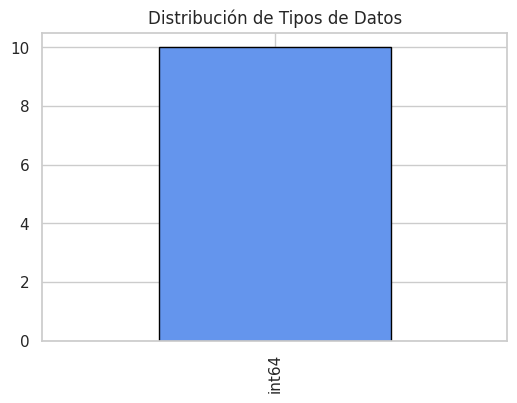

In [461]:
##_indica aquí tu respuesta_
data_types = df.dtypes
print("En el dataset hay:")
print(data_types.value_counts())

plt.figure(figsize=(6, 4))
data_types.value_counts().plot(kind='bar', color='cornflowerblue', edgecolor='black')
plt.title('Distribución de Tipos de Datos')
plt.show()

Todos los datos del conjunto son de tipo **int64**, es decir, numéricas.

#### ¿Son variables continuas o categóricas?

In [462]:
continuas = df.select_dtypes(include=['float64', 'int64']).columns.tolist()
categóricas = df.select_dtypes(include=['object', 'category']).columns.tolist()

print(f"Variables continuas: {continuas}")
print(f"Variables categóricas: {categóricas}")

Variables continuas: ['footfall', 'tempMode', 'AQ', 'USS', 'CS', 'VOC', 'RP', 'IP', 'Temperature', 'fail']
Variables categóricas: []


Como se observa en el resultado de la celda anterior, por defecto no hay ningún valor especificado como categórico, sin embargo, se van a analizar los datos dentro del conjunto y su contexto.

fail            2
USS             7
VOC             7
AQ              7
IP              7
CS              7
tempMode        8
Temperature    24
RP             71
footfall       99
dtype: int64


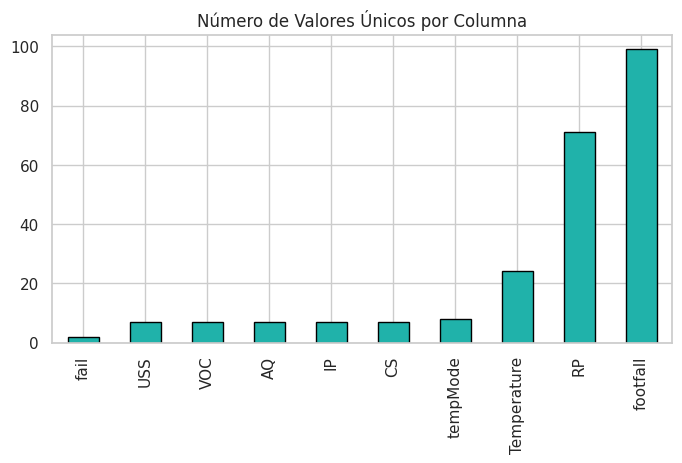

In [463]:
valores_unicos = df.nunique().sort_values()
print(valores_unicos)

plt.figure(figsize=(8, 4))
valores_unicos.plot(kind='bar', color='lightseagreen', edgecolor='black')
plt.title('Número de Valores Únicos por Columna')
plt.show()

In [464]:
df.describe()

,footfall,tempMode,AQ,USS,CS,VOC,RP,IP,Temperature,fail
count,944.000000,944.000000,944.000000,944.000000,944.000000,944.000000,944.000000,944.000000,944.000000,944.000000
mean,306.381356,3.727754,4.325212,2.939619,5.394068,2.842161,47.043432,4.565678,16.331568,0.416314
std,1082.606745,2.677235,1.438436,1.383725,1.269349,2.273337,16.423130,1.599287,5.974781,0.493208
min,0.000000,0.000000,1.000000,1.000000,1.000000,0.000000,19.000000,1.000000,1.000000,0.000000
25%,1.000000,1.000000,3.000000,2.000000,5.000000,1.000000,34.000000,3.000000,14.000000,0.000000
50%,22.000000,3.000000,4.000000,3.000000,6.000000,2.000000,44.000000,4.000000,17.000000,0.000000
75%,110.000000,7.000000,6.000000,4.000000,6.000000,5.000000,58.000000,6.000000,21.000000,1.000000
max,7300.000000,7.000000,7.000000,7.000000,7.000000,6.000000,91.000000,7.000000,24.000000,1.000000


Análisis de la columna: footfall
Valores únicos de footfall:
footfall
0       228
1        19
2        20
3        17
4        15
       ... 
1000      2
1600     12
2800     10
3500      7
7300     18
Name: count, Length: 99, dtype: int64




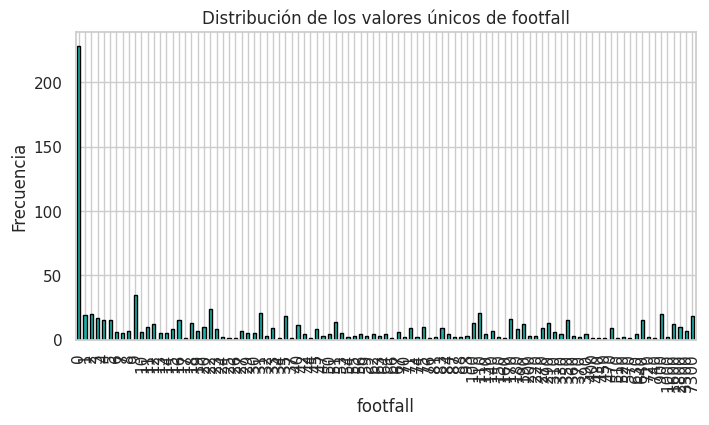

Análisis de la columna: tempMode
Valores únicos de tempMode:
tempMode
0    161
1    100
2    112
3    101
4     66
5     84
6     32
7    288
Name: count, dtype: int64




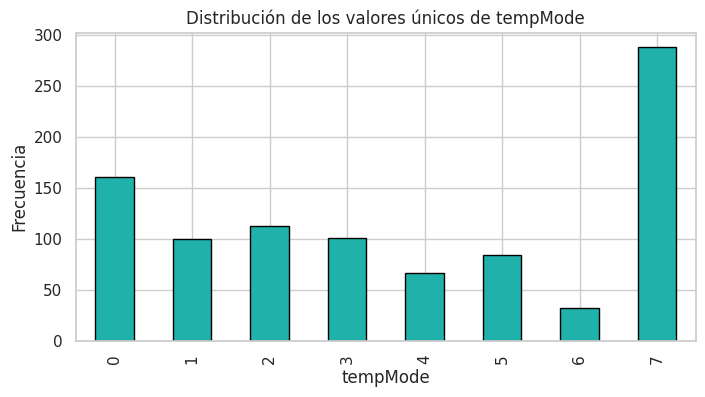

Análisis de la columna: AQ
Valores únicos de AQ:
AQ
1     16
2    103
3    147
4    256
5    170
6    218
7     34
Name: count, dtype: int64




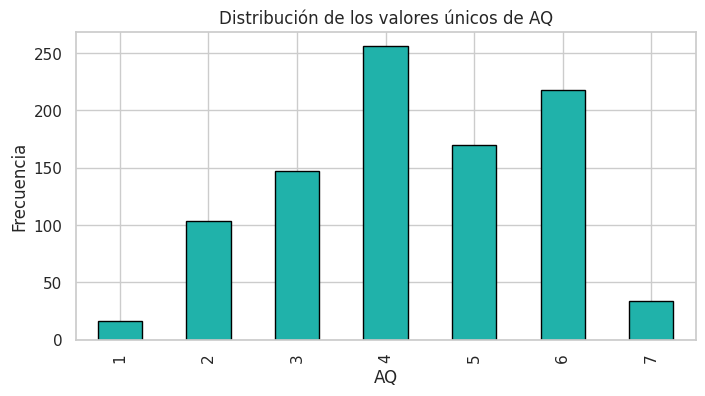

Análisis de la columna: USS
Valores únicos de USS:
USS
1    109
2    317
3    236
4    160
5     67
6     36
7     19
Name: count, dtype: int64




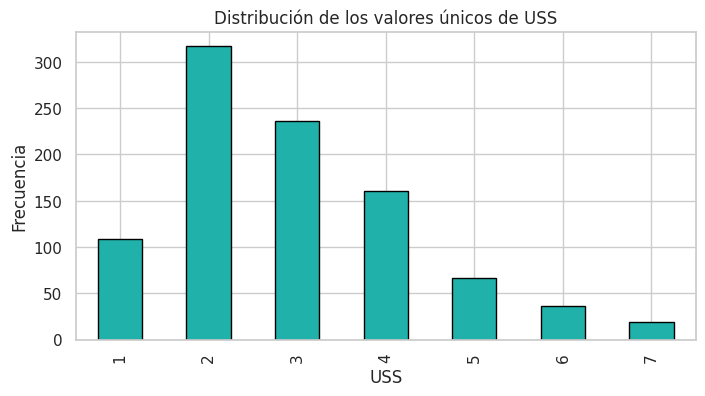

Análisis de la columna: CS
Valores únicos de CS:
CS
1     13
2     31
3     43
4     87
5    195
6    460
7    115
Name: count, dtype: int64




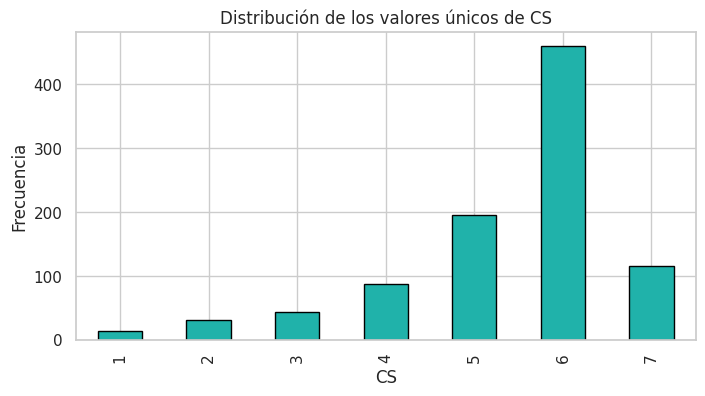

Análisis de la columna: VOC
Valores únicos de VOC:
VOC
0    200
1    180
2    108
3     37
4     94
5    150
6    175
Name: count, dtype: int64




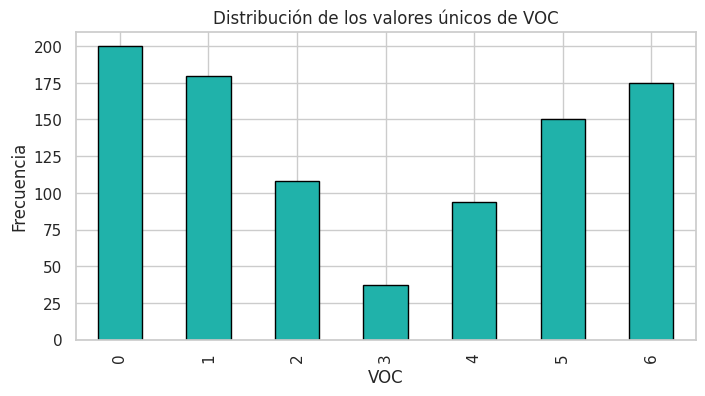

Análisis de la columna: RP
Valores únicos de RP:
RP
19     3
20     6
21    13
22     9
23     6
      ..
85     5
87     4
88     5
89     1
91     2
Name: count, Length: 71, dtype: int64




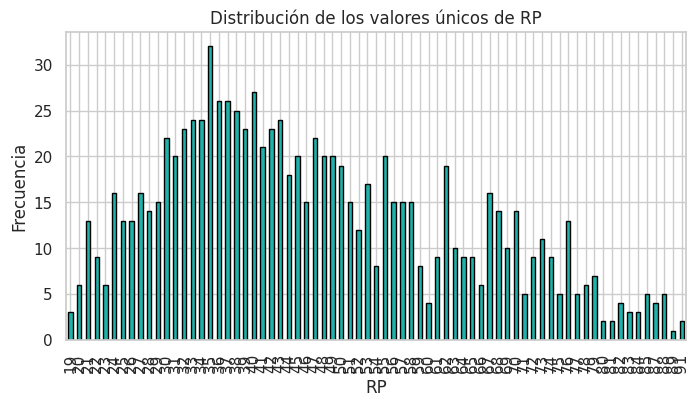

Análisis de la columna: IP
Valores únicos de IP:
IP
1     13
2     52
3    248
4    187
5     90
6    227
7    127
Name: count, dtype: int64




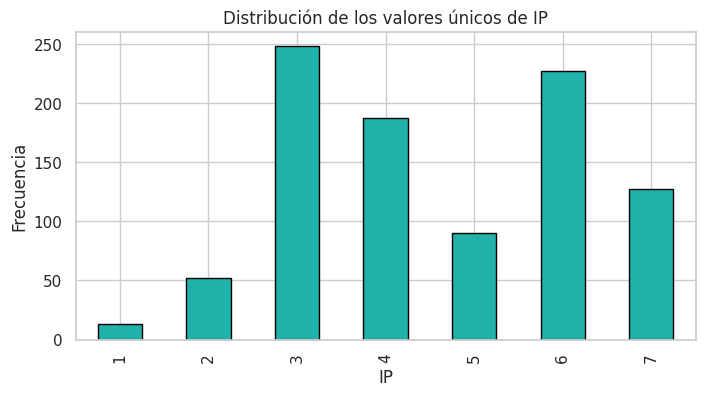

Análisis de la columna: Temperature
Valores únicos de Temperature:
Temperature
1      19
2      12
3      17
4      19
5      18
6      13
7      11
8      17
9      10
10     15
11     23
12     35
13     26
14     39
15     68
16     70
17     62
18     48
19     51
20    100
21    103
22     53
23     47
24     68
Name: count, dtype: int64




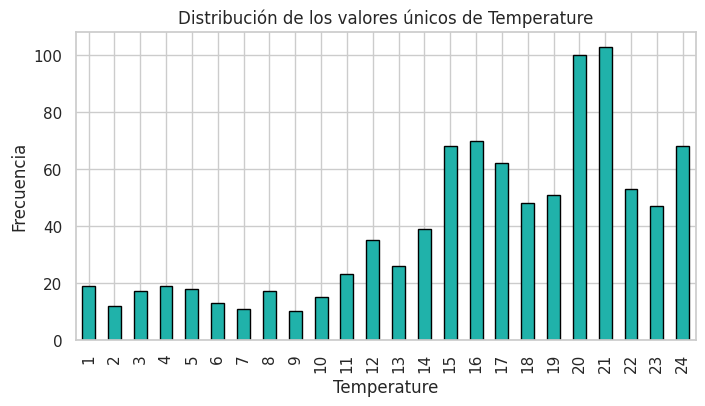

Análisis de la columna: fail
Valores únicos de fail:
fail
0    551
1    393
Name: count, dtype: int64




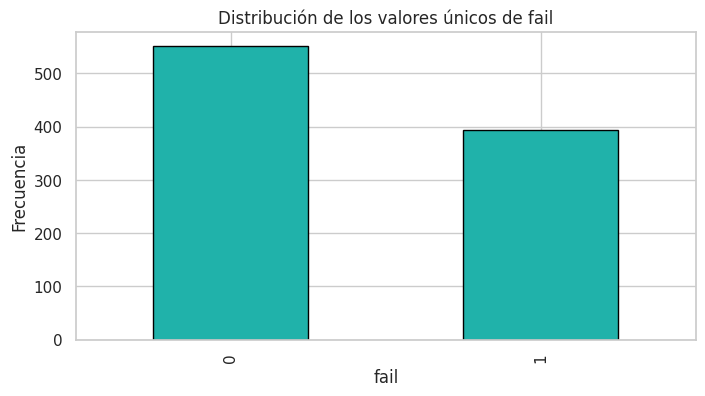

In [465]:
for column in df.columns:
    print(f"Análisis de la columna: {column}")
    unique_values = df[column].value_counts().sort_index()
    print(f"Valores únicos de {column}:")
    print(unique_values)
    print("\n")

    plt.figure(figsize=(8, 4))
    unique_values.plot(kind='bar', color='lightseagreen', edgecolor='black')
    plt.title(f'Distribución de los valores únicos de {column}')
    plt.xlabel(column)
    plt.ylabel('Frecuencia')
    plt.grid(True)
    plt.show()

In [466]:
categoricas = ['fail', 'tempMode', 'USS', 'VOC', 'AQ', 'IP', 'CS']
df[categoricas] = df[categoricas].astype('category')

continuas = df.select_dtypes(include=['float64', 'int64']).columns.tolist()
categóricas = df.select_dtypes(include=['category']).columns.tolist()

print(f"Variables continuas: {continuas}")
print(f"Variables categóricas: {categóricas}")

Variables continuas: ['footfall', 'RP', 'Temperature']
Variables categóricas: ['tempMode', 'AQ', 'USS', 'CS', 'VOC', 'IP', 'fail']


#_indica aquí tu respuesta_

- **Variables categóricas**
  - **fail**: Aunque está codificada como 0 y 1, representa un estado binario (falla o no falla), por lo que es claramente categórica.
  - **tempMode**: Representa un modo de operación. Aunque está codificada numéricamente, tiene un número limitado de configuraciones (0 a 7) que no representan una magnitud continua, sino estados específicos.
   - **USS, VOC, AQ, IP, CS**: Tienen 7 valores únicos cada una. Esto sugiere que no son continuas. Esto es típico de sensores que reportan en "niveles" predefinidos o intervalos discretos. Los sensores industriales a menudo trabajan en rangos fijos para simplificar su calibración y lectura.
- **Variables continuas**
  - **football, Temperature, RP**: Son las únicas que tienen una distribución más amplia de valores únicos.

#### ¿cuáles son los valores mínimo y máximo de la variable 'RP'?

In [467]:
df['RP'].describe()

,RP
count,944.000000
mean,47.043432
std,16.423130
min,19.000000
25%,34.000000
50%,44.000000
75%,58.000000
max,91.000000


Valor mínimo de RP: 19
Valor máximo de RP: 91


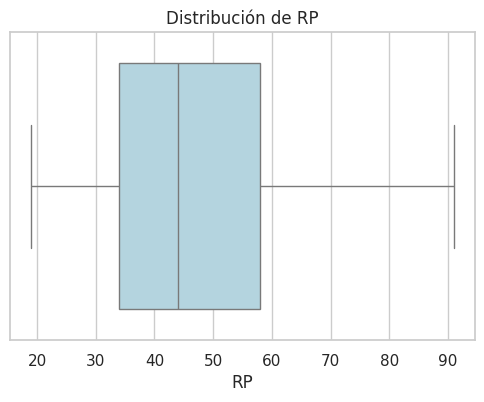

In [468]:
min_rp = df['RP'].min()
max_rp = df['RP'].max()

print(f"Valor mínimo de RP: {min_rp}")
print(f"Valor máximo de RP: {max_rp}")

plt.figure(figsize=(6, 4))
sns.boxplot(x=df['RP'], color='lightblue')
plt.title('Distribución de RP')
plt.show()

### _indica aquí tu respuesta_

El valor mínimo de la variable **RP** (revoluciones por minuto) es 19, mientras que su máximo es 91.

#### Para los algoritmos de clustering el dataset no puede tener instancias con datos faltantes. ¿Tiene este dataset datos faltantes?

In [469]:
valores_nulos = df.isnull().sum()

valores_nulos = valores_nulos[valores_nulos > 0]

if len(valores_nulos) > 0:
    print("Columnas con datos faltantes:")
    print(valores_nulos)
else:
    print("El dataset no tiene datos faltantes.")

El dataset no tiene datos faltantes.


In [470]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 944 entries, 0 to 943
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   footfall     944 non-null    int64   
 1   tempMode     944 non-null    category
 2   AQ           944 non-null    category
 3   USS          944 non-null    category
 4   CS           944 non-null    category
 5   VOC          944 non-null    category
 6   RP           944 non-null    int64   
 7   IP           944 non-null    category
 8   Temperature  944 non-null    int64   
 9   fail         944 non-null    category
dtypes: category(7), int64(3)
memory usage: 30.9 KB


#_indica aquí tu respuesta_

El dataset no tiene datos faltantes, ya que todas las columnas tienen 944 valores no nulos, que es la cantidad de registros ya nombrada anteriormente.

#### Elimine la variable fail

Para pasar de un problema de Aprendizaje Automático Supervisado a no Supervisado se procede a eliminar la variable **fail**.

In [471]:
#_indica aquí tu respuesta_
X = df.drop('fail', axis=1)
y = df['fail']

if 'fail' in df.columns:
  df = df.drop(columns=['fail'])
  fail_in_df = 'fail' in df.columns
  print(f"¿'fail' sigue en el Dataframe trás eliminarlo?: {fail_in_df}")

¿'fail' sigue en el Dataframe trás eliminarlo?: False


La salida del código previo confirma que la columna **fail** ya ha sido eliminada del DataFrame.

#### ¿Es necesario hacer algún tratamiendo adicional sobre los datos?

Antes de realizar cualquier tratamiento a los datos, se va a observar la distribución de las variables y su correlación.

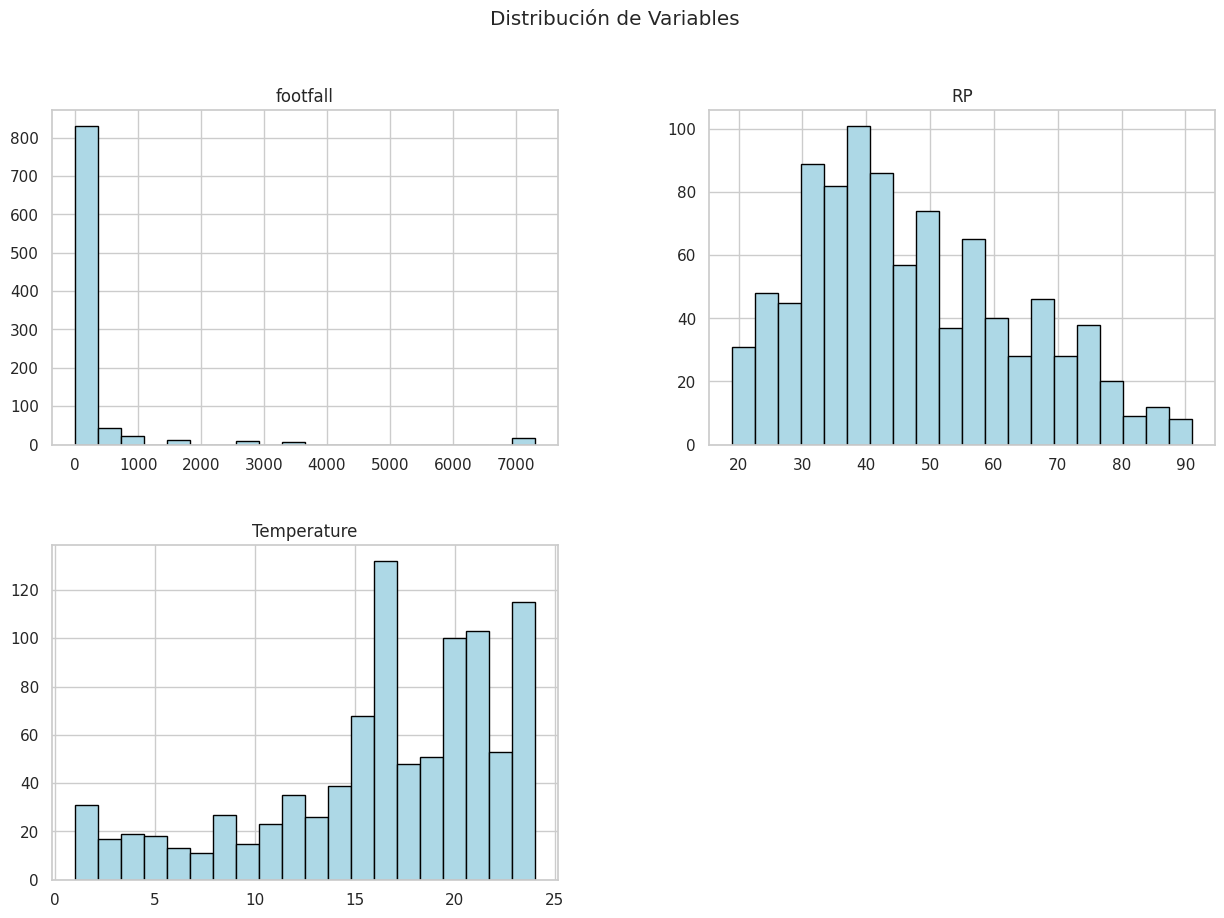

In [472]:
df.hist(bins=20, figsize=(15, 10), color='lightblue', edgecolor='black')
plt.suptitle('Distribución de Variables')
plt.show()

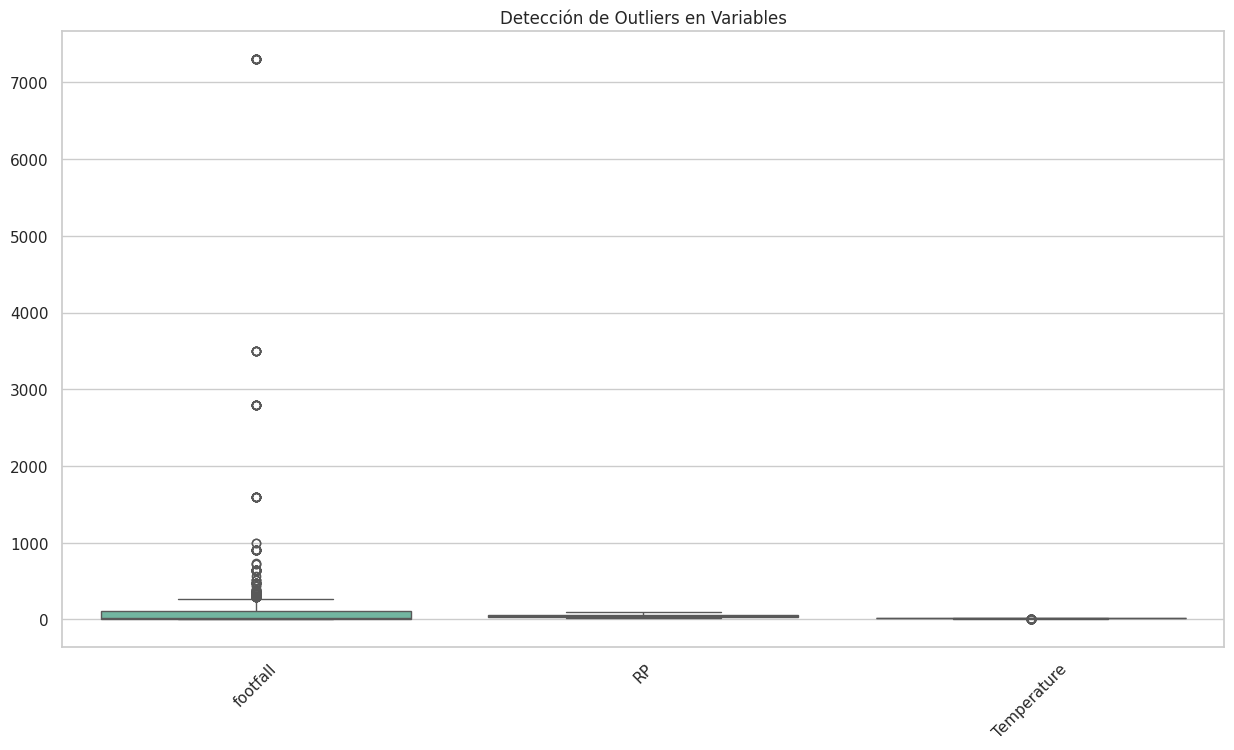

In [473]:
plt.figure(figsize=(15, 8))
sns.boxplot(data=df, palette='Set2')
plt.xticks(rotation=45)
plt.title('Detección de Outliers en Variables')
plt.show()

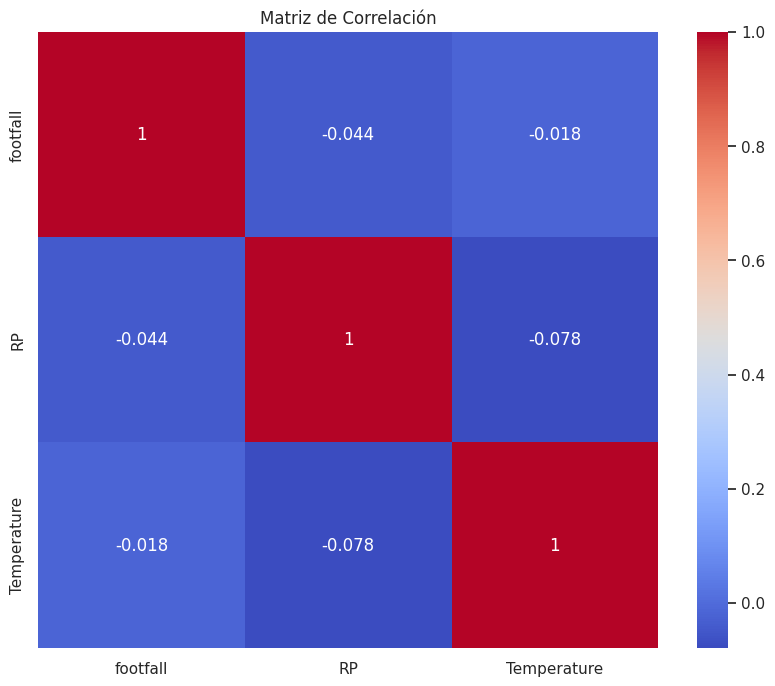

In [474]:
numerical_columns = df.select_dtypes(include=['float64', 'int64']).columns
plt.figure(figsize=(10, 8))
sns.heatmap(df[numerical_columns].corr(), annot=True, cmap='coolwarm')
plt.title('Matriz de Correlación')
plt.show()

- **football**: Presenta una distribución sesgada a la derecha, lo que indica que la mayoría de los valores están concentrados en valores bajos. Hay muchos outliers, dada la distribución sesgada.
- **RP**: También muestra una distribución sesgada a la derecha, pero menos sesgada que **football**. No tiene outliers aparentes.
- **Temperature**: A diferencia de las dos anteriores, tiene una distribución sesgada a la izquierda, con la mayoría de los valores hacia la derecha. Además, se observan algunos outliers.

Ninguna de las correlaciones llega a -+0.1, lo que significa que las variables son bastante independientes entre sí.

##### Log transformation
Para corregir las distribuciones sesgadas nombradas, se va a hacer uso de **Log transformation**.

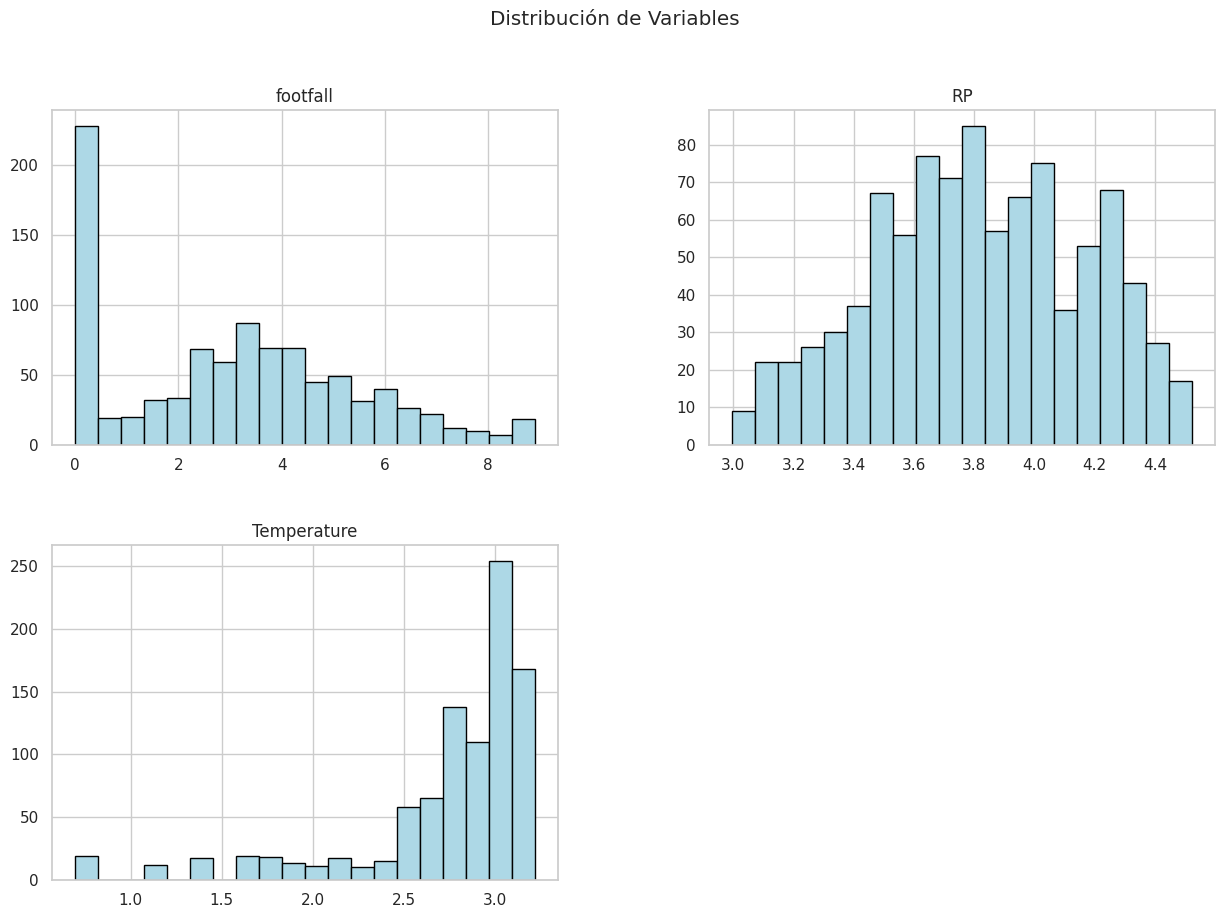

In [475]:
### PON AQUÍ TU CÓDIGO EN CASO DE QUE SEA NECESARIO HACER ALGÚN TRATAMIENTO ADICIONAL
candidatas_log = df.select_dtypes(include=['float64', 'int64'])
for column in candidatas_log.columns:
    df[column] = np.log(df[column] + 1)

df.hist(bins=20, figsize=(15, 10), color='lightblue', edgecolor='black')
plt.suptitle('Distribución de Variables')
plt.show()

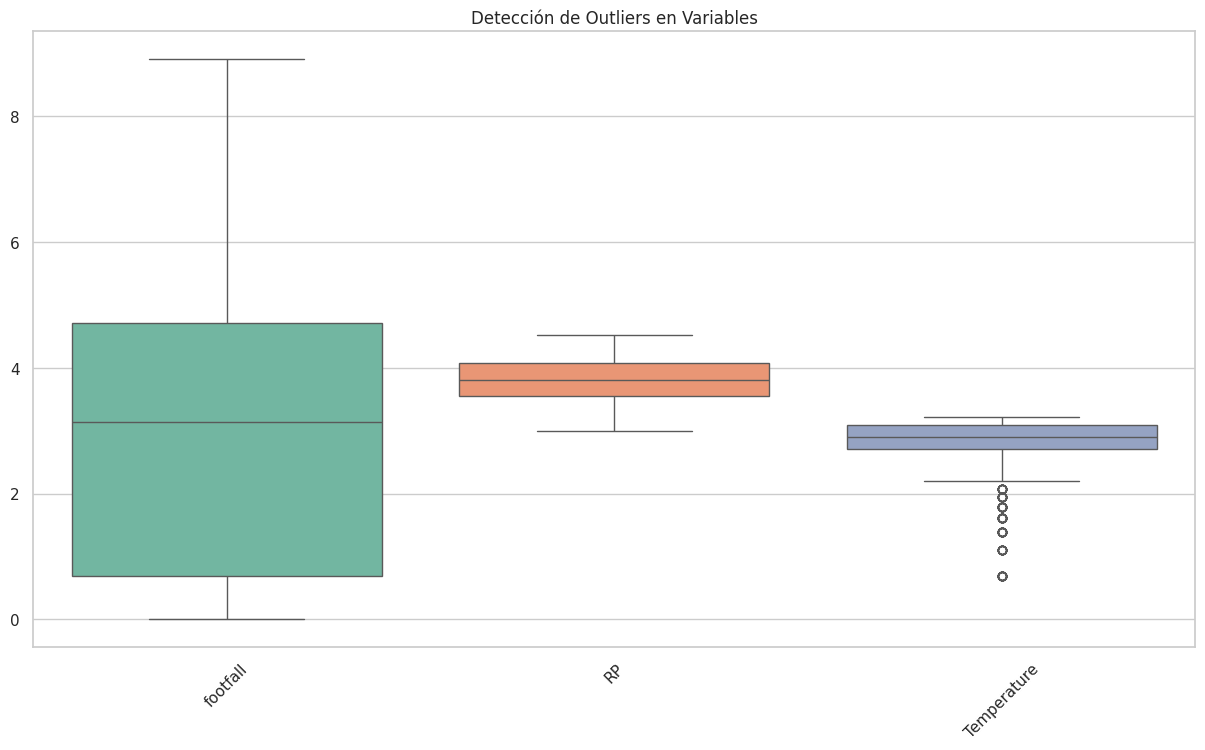

In [476]:
plt.figure(figsize=(15, 8))
sns.boxplot(data=df, palette='Set2')
plt.xticks(rotation=45)
plt.title('Detección de Outliers en Variables')
plt.show()

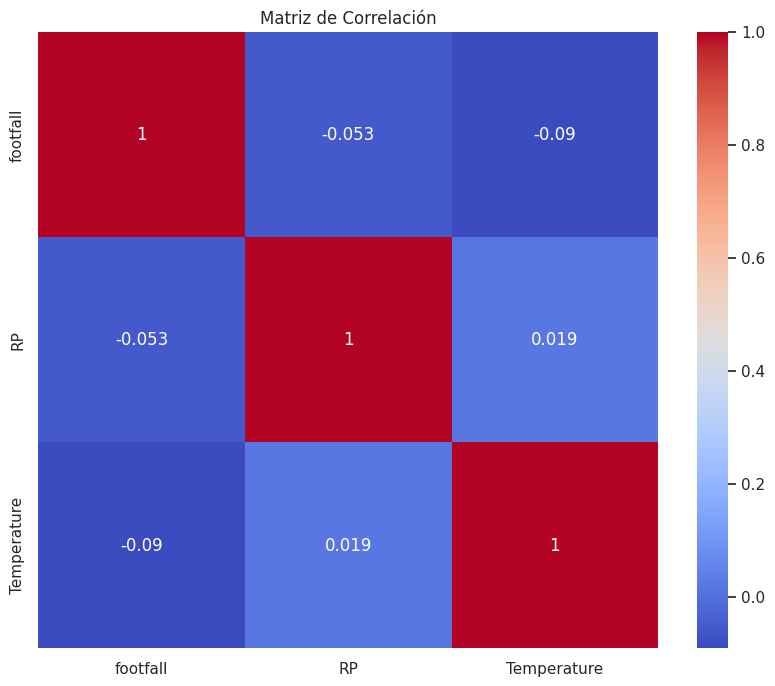

In [477]:
plt.figure(figsize=(10, 8))
sns.heatmap(df[numerical_columns].corr(), annot=True, cmap='coolwarm')
plt.title('Matriz de Correlación')
plt.show()

Tras haber aplicado **Log transformation** en las variables numéricas:

- **RP**: Se asemeja a una distribución normal. Además, hay ausencia de outliers.

- **football**: Aunque también se ha asemejado a una distribución normal, sigue teniendo valores extremos en los bordes. Y los outliers que se encontraban previamente se han eliminado correctamente.

- **Temperature**: En esta variable los outliers siguen persistiendo, aunque esta vez en la zona baja de la caja. Además, es la que tiene la distribución más sesgada de las tres.


En cuanto a la correlación, los valores han aumentado y disminuido ligeramente, no ha alterado las relaciones lineales de forma drástica.

##### StandardScaler
Se ha decidido escalar las variables numéricas para asegurar que todas las características tengan el mismo rango y contribuyan de manera equitativa al cálculo de distancias, lo cual es importante para algoritmos que se basan en estas mismas.

Para escalar, se ha utilizado **StandardScaler** debido a su capacidad para transformar las variables de manera que cada una tenga una media de 0 y una desviación estándar de 1. Evitando así que las distancias sean influenciadas de manera desproporcionada por algunas características con rangos más amplios. **StandardScaler** es particularmente útil para algoritmos que dependen de distancias, como **K-means**, ya que mantiene la información de la distribución de las variables.

In [478]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df_scaled = scaler.fit_transform(df[numerical_columns].values)
df_scaled = pd.DataFrame(df_scaled, columns=numerical_columns)
df_scaled.head()

,footfall,RP,Temperature
0,-1.291680,-0.585075,-3.843551
1,0.913523,-2.222372,-3.843551
2,0.163433,-1.718363,-3.843551
3,0.568629,-1.289321,-3.843551
4,1.421867,1.216395,-3.843551


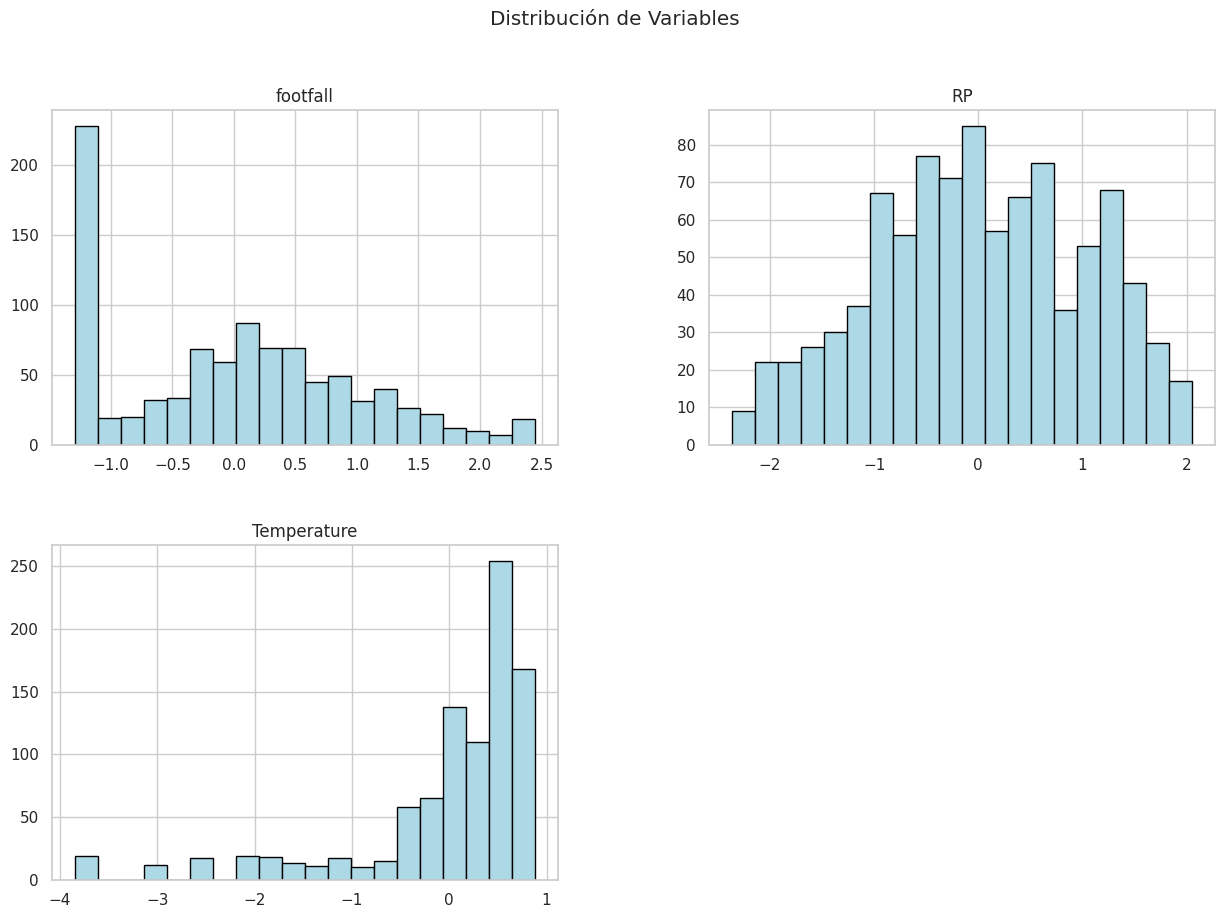

In [479]:
df_scaled.hist(bins=20, figsize=(15, 10), color='lightblue', edgecolor='black')
plt.suptitle('Distribución de Variables')
plt.show()

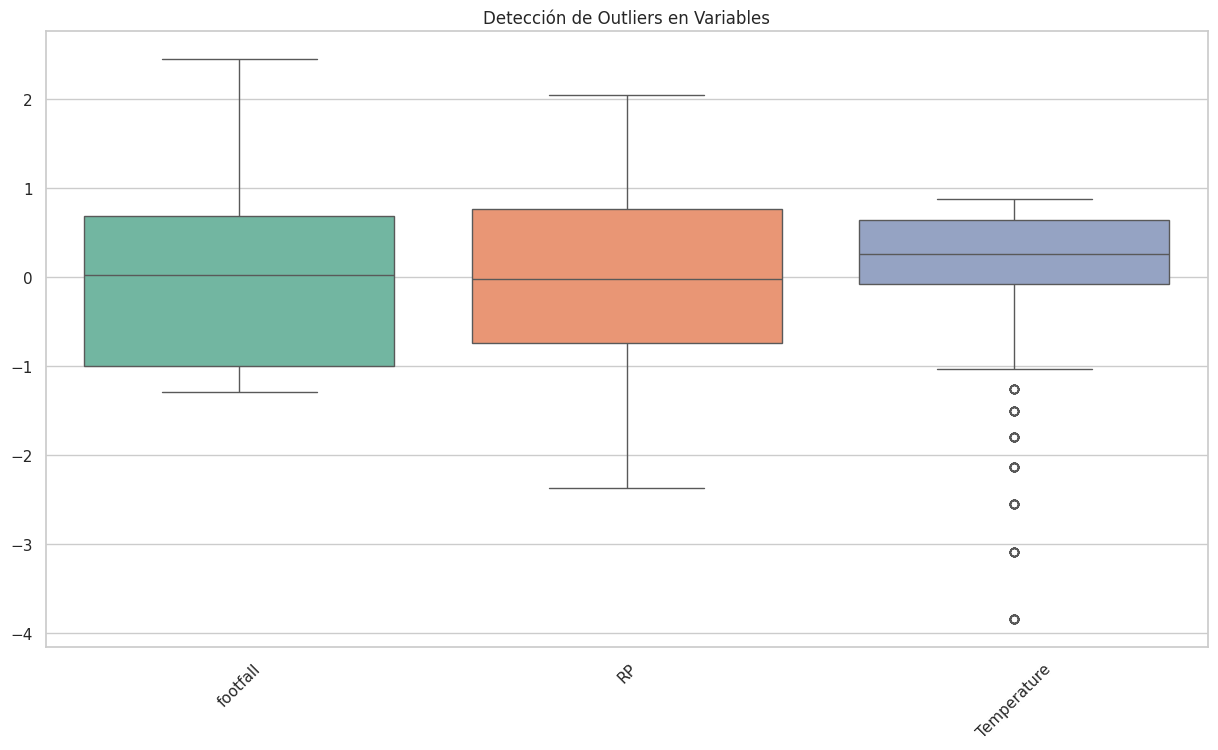

In [480]:
plt.figure(figsize=(15, 8))
sns.boxplot(data=df_scaled, palette='Set2')
plt.xticks(rotation=45)
plt.title('Detección de Outliers en Variables')
plt.show()

#### One-Hot Encoding
Tras aplicar el escalado, como se puede observar en las gráficas anteriores, los valores de las variables se han ajustado a un rango más homogéneo. Para el caso de las variables categóricas, se procede a aplicar la técnica de **One-Hot Encoding**, convirtiendo así las variables categóricas en variables binarias, creando una columna por cada categoría posible en cada variable.

In [481]:
categorical_columns = df.select_dtypes(include=['object', 'category']).columns.tolist()
df_encoded = pd.get_dummies(df, columns=categorical_columns, drop_first=True)
df_encoded = df_encoded.astype(int)
df_encoded.head()

,footfall,RP,Temperature,tempMode_1,tempMode_2,tempMode_3,tempMode_4,tempMode_5,tempMode_6,tempMode_7,...,VOC_3,VOC_4,VOC_5,VOC_6,IP_2,IP_3,IP_4,IP_5,IP_6,IP_7
0,0,3,0,0,0,0,0,0,0,1,...,0,0,0,1,0,1,0,0,0,0
1,5,3,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0
2,3,3,0,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,1,0
3,4,3,0,0,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,1,0
4,6,4,0,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,1,0


Finalmente, después de aplicar **One-Hot Encoding** y **StandardScaler**, las variables se combinaron en un único DataFrame.

In [482]:
df_final = pd.concat([df_scaled, df_encoded.drop(columns=numerical_columns)], axis=1)
df_final.head()

,footfall,RP,Temperature,tempMode_1,tempMode_2,tempMode_3,tempMode_4,tempMode_5,tempMode_6,tempMode_7,...,VOC_3,VOC_4,VOC_5,VOC_6,IP_2,IP_3,IP_4,IP_5,IP_6,IP_7
0,-1.291680,-0.585075,-3.843551,0,0,0,0,0,0,1,...,0,0,0,1,0,1,0,0,0,0
1,0.913523,-2.222372,-3.843551,1,0,0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0
2,0.163433,-1.718363,-3.843551,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,1,0
3,0.568629,-1.289321,-3.843551,0,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,1,0
4,1.421867,1.216395,-3.843551,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,1,0


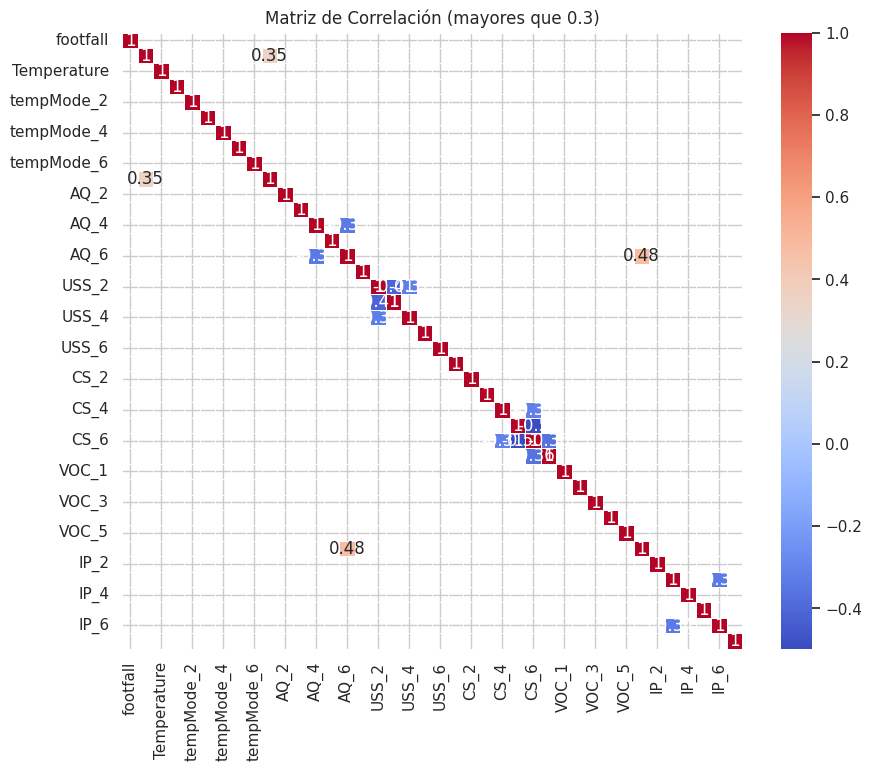

In [483]:
umbral = 0.3

corr_matrix = df_final.corr()

mask = np.abs(corr_matrix) > umbral
filtered_corr = corr_matrix.where(mask)

plt.figure(figsize=(10, 8))
sns.heatmap(filtered_corr, annot=True, cmap='coolwarm', cbar=True, linewidths=0.5)
plt.title(f'Matriz de Correlación (mayores que {umbral})')
plt.show()

Tras el preprocesamiento, la correlación más alta es 0.48, además, tras **One-Hot Encoding** ha aumentado significativamente el número de las variables. Por lo que la técnica de **PCA (Análisis de Componentes Principales)** podría ser útil.

Varianza explicada por cada componente: [0.15857903 0.14427486 0.12612693 0.05220949 0.04620968 0.03766166
 0.0333498  0.03081147 0.02904545 0.0276725  0.02620964 0.0251125
 0.02213002 0.01970975 0.0193367  0.01742479 0.01717546 0.0160519
 0.01486336 0.01436697 0.0138645  0.012965   0.0118643  0.01112847
 0.01086906 0.00980395 0.00761896]
Total de varianza explicada: 0.9564361912461357


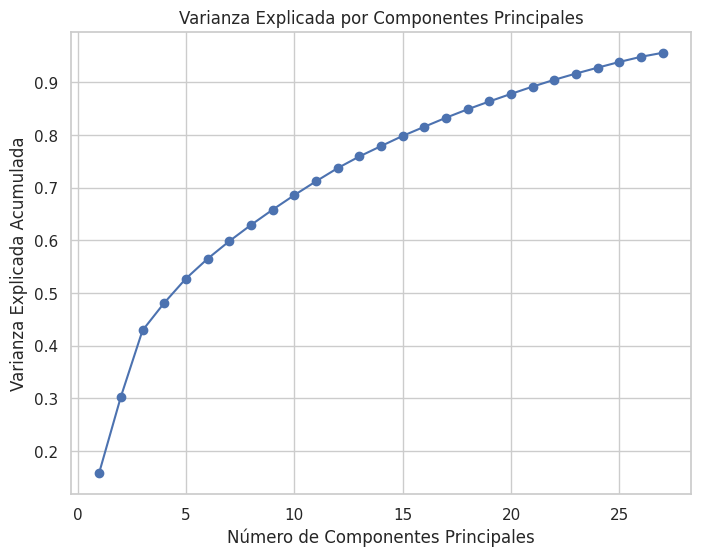

In [484]:
from sklearn.decomposition import PCA

pca = PCA(n_components=0.95)
df_pca = pca.fit_transform(df_final)

print(f"Varianza explicada por cada componente: {pca.explained_variance_ratio_}")
print(f"Total de varianza explicada: {np.sum(pca.explained_variance_ratio_)}")

plt.figure(figsize=(8, 6))
plt.plot(range(1, len(pca.explained_variance_ratio_) + 1), np.cumsum(pca.explained_variance_ratio_), marker='o')
plt.title('Varianza Explicada por Componentes Principales')
plt.xlabel('Número de Componentes Principales')
plt.ylabel('Varianza Explicada Acumulada')
plt.grid(True)
plt.show()

Esto nos indica que con las primeras 27 componentes principales se explica un 95.6% de la varianza total del conjunto de datos. Permitiendo reducir considerablemente el número de dimensiones (de 40 a 27) sin perder demasiada información.

## K-Means

Crea 10 modelos de KMeans y entrénalos. Haciendo uso del método indicado para saber el número ideal de clústeres.

In [485]:
df_scaled_kmeans = df_scaled.copy()
df_pca_kmeans = df_pca.copy()
df_final_kmeans = df_final.copy()

Para que el algoritmo de KMeans tenga sentido, debe haber al menos 2 clústeres (K ≥ 2). A partir de 2, podemos comenzar a identificar diferencias y similitudes dentro de los datos.

In [486]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

def evaluate_kmeans(data, max_k=10, title_suffix=""):
    silhouette_scores = []
    inertia_values = []
    davies_bouldin_scores = []
    calinski_harabasz_scores = []
    models = []
    K_values = range(2, max_k + 1)

    for k in K_values:
        kmeans = KMeans(n_clusters=k, init='random', n_init=1, random_state=42)
        kmeans.fit(data)
        models.append(kmeans)  # Guardar el modelo

        cluster_labels = kmeans.labels_

        silhouette_avg = silhouette_score(data, cluster_labels)
        davies_bouldin_avg = davies_bouldin_score(data, cluster_labels)
        calinski_harabasz_avg = calinski_harabasz_score(data, cluster_labels)
        inertia = kmeans.inertia_

        silhouette_scores.append(silhouette_avg)
        davies_bouldin_scores.append(davies_bouldin_avg)
        calinski_harabasz_scores.append(calinski_harabasz_avg)
        inertia_values.append(inertia)

    plt.figure(figsize=(12, 8))

    plt.subplot(2, 2, 1)
    plt.plot(K_values, silhouette_scores, marker='o', color='blue')
    plt.title(f'Silhouette Score vs K - {title_suffix}')
    plt.xlabel('Number of Clusters (K)')
    plt.ylabel('Silhouette Score')
    plt.grid(True)

    plt.subplot(2, 2, 2)
    plt.plot(K_values, inertia_values, marker='o', color='green')
    plt.title(f'Inertia vs K - {title_suffix}')
    plt.xlabel('Number of Clusters (K)')
    plt.ylabel('Inertia')
    plt.grid(True)

    plt.subplot(2, 2, 3)
    plt.plot(K_values, davies_bouldin_scores, marker='o', color='red')
    plt.title(f'Davies-Bouldin Index vs K - {title_suffix}')
    plt.xlabel('Number of Clusters (K)')
    plt.ylabel('Davies-Bouldin Index')
    plt.grid(True)

    plt.subplot(2, 2, 4)
    plt.plot(K_values, calinski_harabasz_scores, marker='o', color='purple')
    plt.title(f'Calinski-Harabasz Index vs K - {title_suffix}')
    plt.xlabel('Number of Clusters (K)')
    plt.ylabel('Calinski-Harabasz Index')
    plt.grid(True)

    plt.tight_layout()
    plt.show()

    optimal_k_silhouette = np.argmax(silhouette_scores)
    best_model = models[optimal_k_silhouette]

    print(f"Mejor modelo según Silhouette Score: {optimal_k_silhouette + 2} clusters")

    return best_model

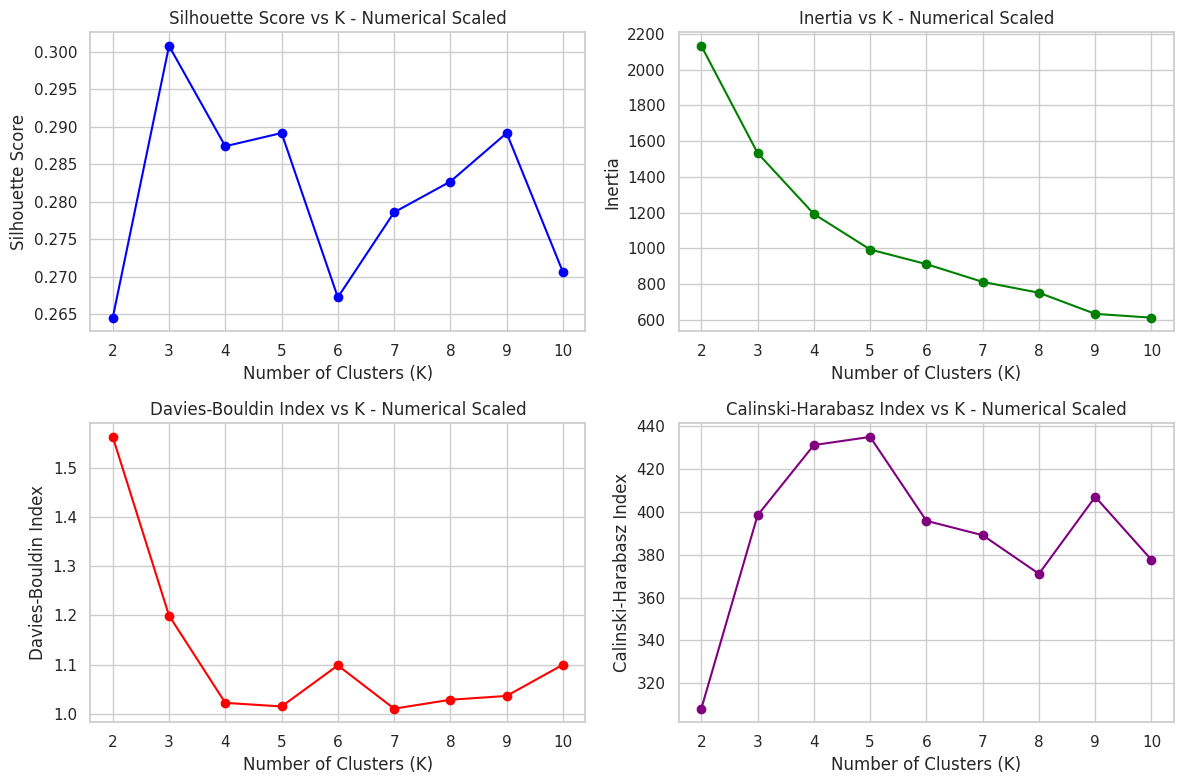

Mejor modelo según Silhouette Score: 3 clusters


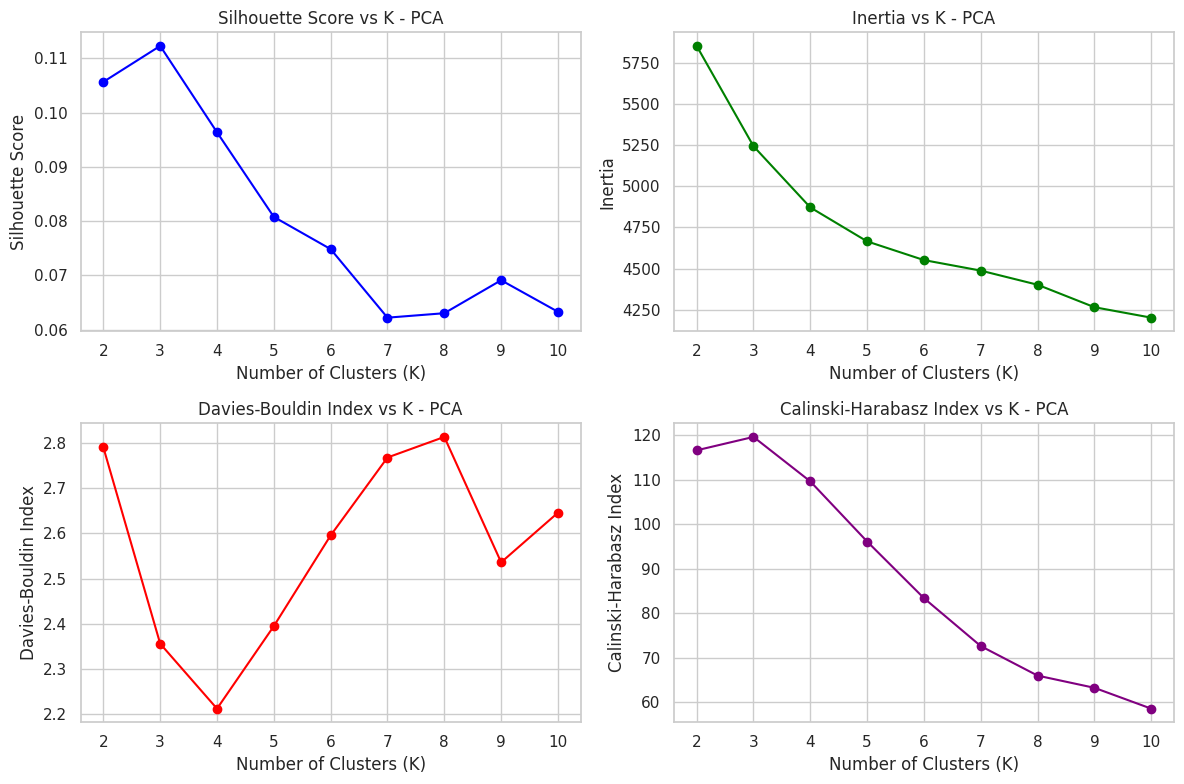

Mejor modelo según Silhouette Score: 3 clusters


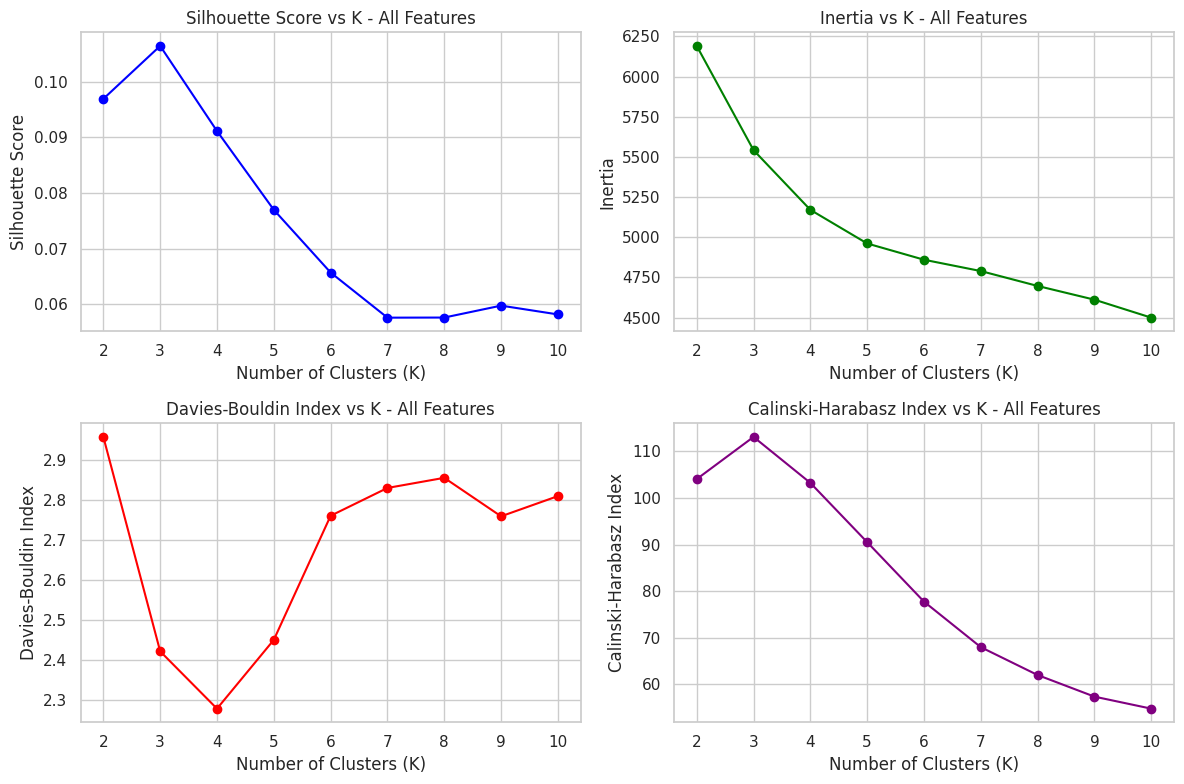

Mejor modelo según Silhouette Score: 3 clusters


In [487]:
kmeans_scaled = evaluate_kmeans(df_scaled_kmeans, max_k=10, title_suffix="Numerical Scaled")
kmeans_pca = evaluate_kmeans(df_pca_kmeans, max_k=10, title_suffix="PCA")
kmeans_final = evaluate_kmeans(df_final_kmeans, max_k=10, title_suffix="All Features")

- **Silhouette Score**
  - Para todos los casos (datos escalados, con PCA y el conjunto final con One-Hot Encoding), el número óptimo de clústeres es 3.
- **Davies-Bouldin Index**
  - El valor óptimo de K según el Davies-Bouldin Index varía entre 4 y 7.
- **Calinski-Harabasz Index**
  - El valor óptimo de K según el Calinski-Harabasz Index es 3 para todos los casos.
- **Inercia**
  - El número de clústeres más bajo para el Inertia es 10 en todos los casos.

K = 3 parece ser el número de clústeres más consistente y recomendado, basándose en el Silhouette Score, Calinski-Harabasz Index y el Davies-Bouldin Index. Este valor sugiere una buena separación y cohesión de los clústeres.

Ahora toca interpretar lo que Kmeans ha realizado. Recordemos que el objetivo de KMeans es encontrar patrones en los datos.

Lo primero que vamos a realizar es un gráfico para visualizar los clústers que ha creado con base en las variables utilizadas para crearlos.

In [488]:
import plotly.express as px
import pandas as pd

def plot_polar_kmeans(data, model, title):
    clusters = pd.DataFrame(data, columns=data.columns if isinstance(data, pd.DataFrame) else [f'PC{i}' for i in range(data.shape[1])])
    clusters['label'] = model.labels_
    polar = clusters.groupby("label").mean().reset_index()
    polar = pd.melt(polar, id_vars=["label"])
    fig = px.line_polar(polar, r="value", theta="variable", color="label", line_close=True, height=800, width=600)
    fig.update_layout(title=title)
    fig.show()

plot_polar_kmeans(df_scaled_kmeans, kmeans_scaled, "Gráfico Polar - KMeans (Scaled Variables)")
plot_polar_kmeans(df_pca_kmeans, kmeans_pca, "Gráfico Polar - KMeans (PCA Variables)")
plot_polar_kmeans(df_final_kmeans, kmeans_final, "Gráfico Polar - KMeans (One Hot Encoding)")


- **Scaled**
  - Los tres clústeres tienen una estructura triangular al tener tres variables.
  - **Temperature**
    - Muy similar en los tres clústeres, lo cual sugiere que esta variable podría no ser determinante para diferenciar el comportamiento de las máquinas en este contexto.
    - **RP**
      -  Existen diferencias más marcadas, lo cual podría indicar que hay máquinas que operan en distintos niveles de revolución.
    - **fotball**
      - Es la variable con mayor diferencia entre clústeres, con una separación clara de aproximadamente 0.5 de diferencia por clúster.
- **PCA**
  - Son circulares y bastante similares entre sí, aunque con pequeñas desviaciones en algunas componentes principales.
  - **Cluster 0**
    -  Pico significativo en **PC0** y **PC1**, mientras que en **PC2** disminuye. Esto indica que los datos están más representados en estas dos primeras componentes.
  - **Cluster 1**
    - Dos picos también en **PC0** y **PC1**.
  - **Cluster 2**
    - Es el más estable, con menor rango de variación en todas las componentes.
- **Final**
  - Son similares al PCA (circulares), pero con mayor expansión y variabilidad en los bordes.
  - **Cluster 0**
    - Gran variación en **Temperature**, donde baja cerca de 0. Esto podría sugerir un estado de baja actividad.
  - **Cluster 1**
    - Picos notables en **footfall**, **TP**, y **Temperature**. Esto podría representar máquinas en alta actividad.
  - **Cluster 2**
    - Muy parecido al Clúster 1, pero con un comportamiento ligeramente más estable.

  

In [489]:
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score

def calculate_metrics(X, model):
    silhouette = silhouette_score(X, model.labels_)
    inertia = model.inertia_
    calinski_harabasz = calinski_harabasz_score(X, model.labels_)
    davies_bouldin = davies_bouldin_score(X, model.labels_)

    return silhouette, inertia, calinski_harabasz, davies_bouldin

metrics_scaled = calculate_metrics(df_scaled_kmeans, kmeans_scaled)
metrics_pca = calculate_metrics(df_pca_kmeans, kmeans_pca)
metrics_final = calculate_metrics(df_final_kmeans, kmeans_final)

print("Métricas para el conjunto de datos escalado:")
print(f"Silhouette Score: {metrics_scaled[0]:.4f}")
print(f"Inercia: {metrics_scaled[1]:.4f}")
print(f"Calinski-Harabasz Index: {metrics_scaled[2]:.4f}")
print(f"Davies-Bouldin Index: {metrics_scaled[3]:.4f}")

print("\nMétricas para el conjunto de datos PCA:")
print(f"Silhouette Score: {metrics_pca[0]:.4f}")
print(f"Inercia: {metrics_pca[1]:.4f}")
print(f"Calinski-Harabasz Index: {metrics_pca[2]:.4f}")
print(f"Davies-Bouldin Index: {metrics_pca[3]:.4f}")

print("\nMétricas para el conjunto de datos final:")
print(f"Silhouette Score: {metrics_final[0]:.4f}")
print(f"Inercia: {metrics_final[1]:.4f}")
print(f"Calinski-Harabasz Index: {metrics_final[2]:.4f}")
print(f"Davies-Bouldin Index: {metrics_final[3]:.4f}")


Métricas para el conjunto de datos escalado:
Silhouette Score: 0.3008
Inercia: 1533.4063
Calinski-Harabasz Index: 398.4517
Davies-Bouldin Index: 1.1995

Métricas para el conjunto de datos PCA:
Silhouette Score: 0.1123
Inercia: 5243.0072
Calinski-Harabasz Index: 119.5712
Davies-Bouldin Index: 2.3555

Métricas para el conjunto de datos final:
Silhouette Score: 0.1064
Inercia: 5542.3152
Calinski-Harabasz Index: 113.1300
Davies-Bouldin Index: 2.4228


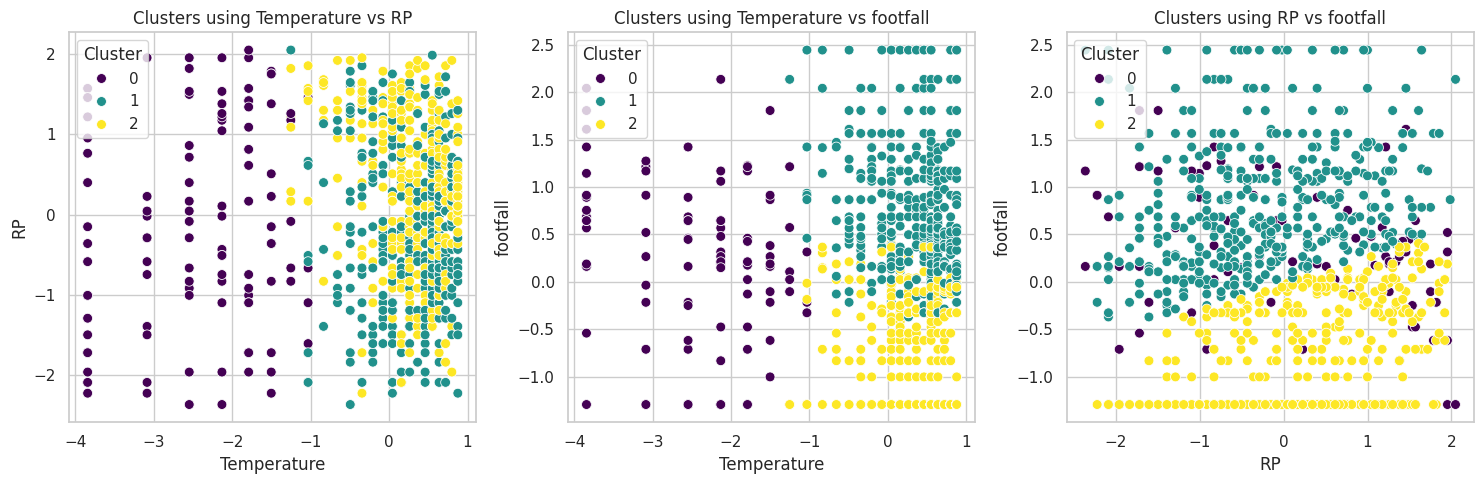

In [490]:
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import combinations

df_scaled_viz = pd.DataFrame(df_scaled_kmeans, columns=['Temperature', 'RP', 'footfall'])
df_scaled_viz['Cluster'] = kmeans_scaled.labels_

feature_pairs = list(combinations(['Temperature', 'RP', 'footfall'], 2))

plt.figure(figsize=(15, 5))
for idx, (feature_x, feature_y) in enumerate(feature_pairs, 1):
    plt.subplot(1, 3, idx)
    sns.scatterplot(data=df_scaled_viz, x=feature_x, y=feature_y, hue='Cluster', palette='viridis', s=50)
    plt.title(f'Clusters using {feature_x} vs {feature_y}')
    plt.grid(True)

plt.tight_layout()
plt.show()


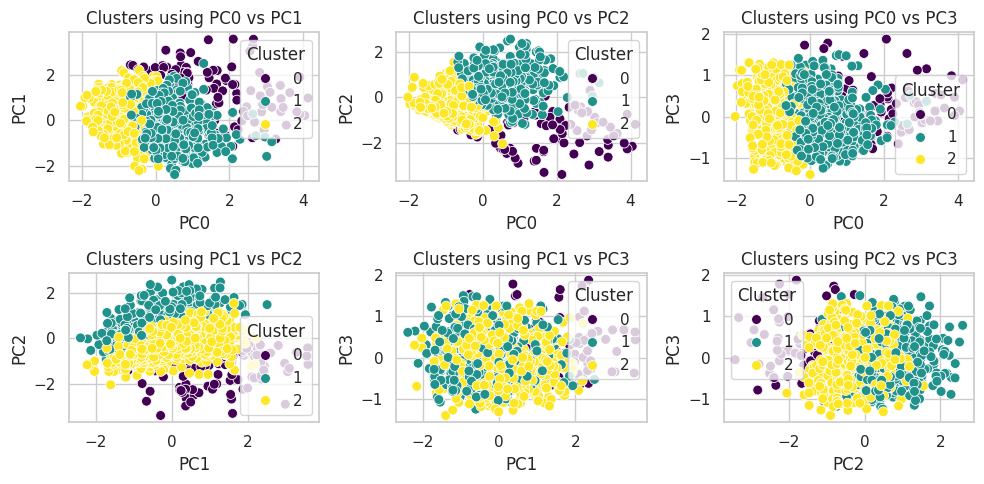

In [491]:
df_pca_viz = df_pca_kmeans[:, :4]
df_pca_viz = pd.DataFrame(df_pca_viz, columns=['PC0', 'PC1', 'PC2', 'PC3'])
df_pca_viz['Cluster'] = kmeans_pca.labels_

feature_pairs_pca = list(combinations(['PC0', 'PC1', 'PC2', 'PC3'], 2))

plt.figure(figsize=(10, 5))
for idx, (feature_x, feature_y) in enumerate(feature_pairs_pca, 1):
    plt.subplot(2, 3, idx)
    sns.scatterplot(data=df_pca_viz, x=feature_x, y=feature_y, hue='Cluster', palette='viridis', s=50)
    plt.title(f'Clusters using {feature_x} vs {feature_y}')
    plt.grid(True)

plt.tight_layout()
plt.show()


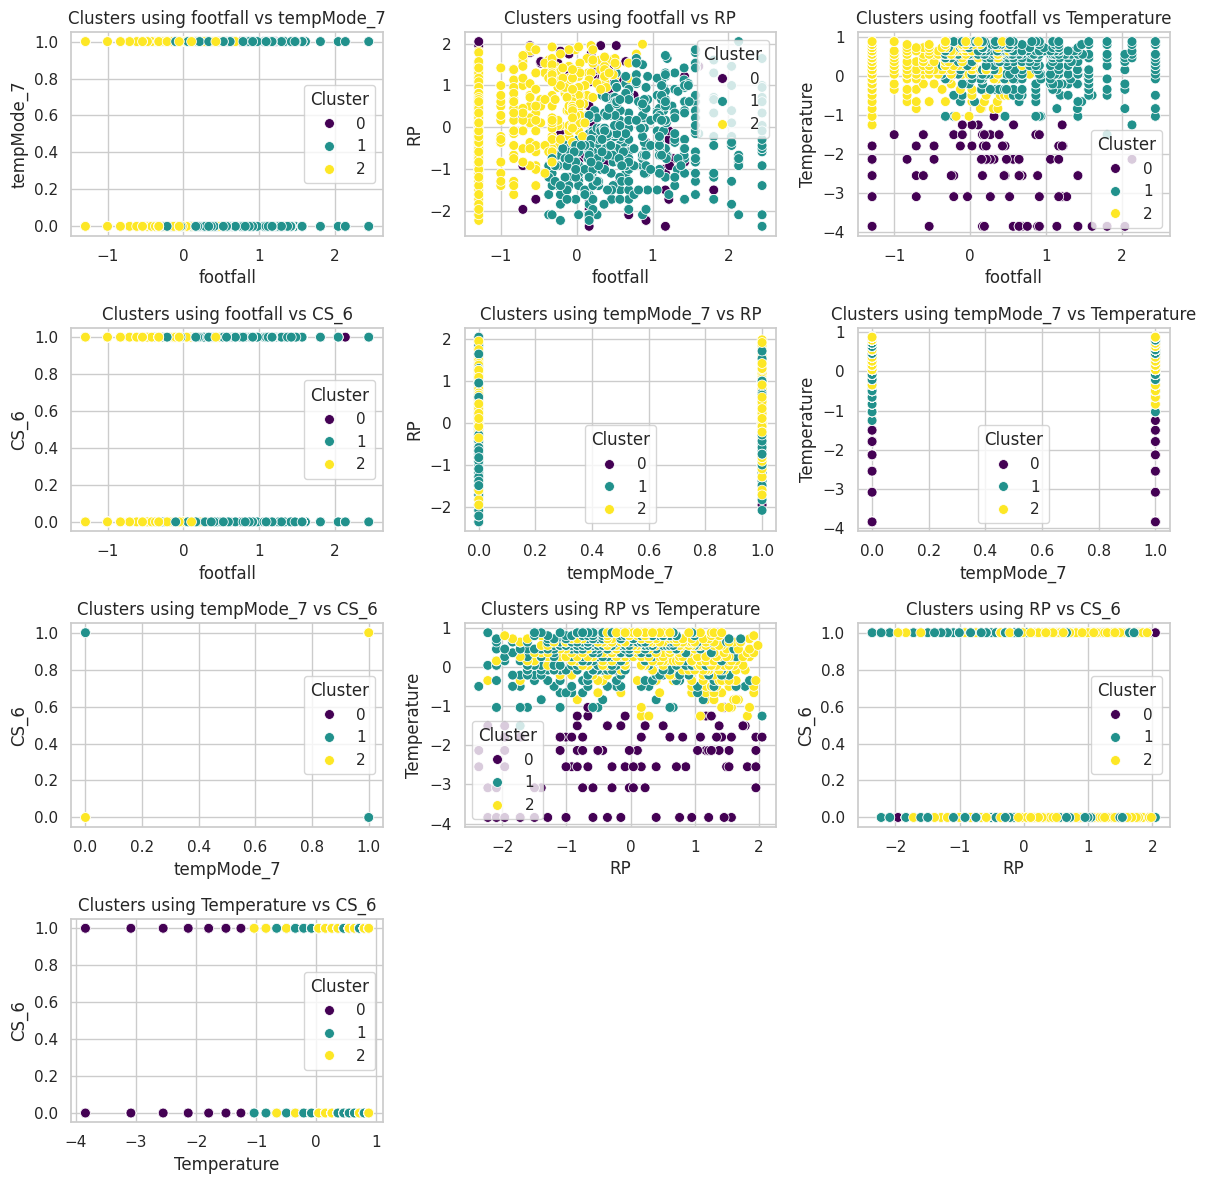

In [492]:
variables_final = ['footfall', 'tempMode_7', 'RP', 'Temperature', 'CS_6']

df_final_viz = pd.DataFrame(df_final_kmeans, columns=variables_final)
df_final_viz['Cluster'] = kmeans_final.labels_

feature_pairs_final = list(combinations(variables_final, 2))

plt.figure(figsize=(12, 12))
for idx, (feature_x, feature_y) in enumerate(feature_pairs_final, 1):
    plt.subplot(4, 3, idx)
    sns.scatterplot(data=df_final_viz, x=feature_x, y=feature_y, hue='Cluster', palette='viridis', s=50)
    plt.title(f'Clusters using {feature_x} vs {feature_y}')
    plt.grid(True)

plt.tight_layout()
plt.show()


- **Scaled**
  - Las métricas indican que el modelo de clústeres para el conjunto de datos escalado tiene una separación moderada entre los clústeres, con una dispersión controlada dentro de cada uno. La visualización confirma que algunos clústeres se superponen, pero la separación es más evidente en algunas combinaciones de características, como **Footfall** vs **Temperature**, donde los clústeres 1 y 2 están mejor diferenciados.
- **PCA**
  - El modelo de **PCA** tiene métricas más bajas, lo que se refleja en la visualización, ya que los clústeres no están bien separados. Las distancias entre los clústeres son pequeñas, y los puntos tienden a superponerse más entre sí, sobre todo el clúster 0. Esto sugiere que la reducción dimensional con **PCA** no proporciona una separación clara entre los clústeres.
- **Final**
  - En el conjunto de datos final, a pesar de que algunas combinaciones de características, como **Footfall** vs **Temperature**, muestran una buena separación, las métricas sugieren que los clústeres no están completamente bien definidos. La dispersión es alta y hay solapamientos, especialmente en algunas combinaciones de características como **RP** vs **Temperature**. Aún así, la separación en **Footfall** vs **Temperature** es una de las más destacadas en este conjunto.



## DBSCAN

In [493]:
df_scaled_dbscan = df_scaled.copy()
df_pca_dbscan = df_pca.copy()
df_final_dbscan = df_final.copy()

In [494]:
#### Realiza una búsqueda de los mejores hiperparámetros para el algoritmo

In [495]:
param_grid = {
    'eps': np.arange(0.1, 2.1, 0.2),
    'min_samples': range(2, 10)
}

silhouette_scorer = make_scorer(silhouette_score)

results_dbscan = {}

datasets = {
    'Scaled': df_scaled_dbscan,
    'PCA': df_pca_dbscan,
    'Final': df_final_dbscan
}

for name, data in datasets.items():
    best_silhouette = -1
    best_params = None


    for eps in eps_range:
        for min_samples in min_samples_range:
            model = DBSCAN(eps=eps, min_samples=min_samples)
            labels = model.fit_predict(data)

            if len(set(labels)) > 1 and len(set(labels)) != 1 + (labels == -1).sum():
                silhouette = silhouette_score(data, labels)
                db_index = davies_bouldin_score(data, labels)

                # Guardar el mejor
                if silhouette > best_silhouette:
                    best_silhouette = silhouette
                    best_params = {
                        'eps': eps,
                        'min_samples': min_samples,
                        'silhouette': silhouette,
                        'davies_bouldin': db_index,
                        'n_clusters': len(set(labels)) - (1 if -1 in labels else 0)
                    }
    results_dbscan[name] = best_params

results_dbscan

{'Scaled': {'eps': np.float64(1.1000000000000003),
  'min_samples': 6,
  'silhouette': np.float64(0.49440398356110765),
  'davies_bouldin': np.float64(0.7176616120605753),
  'n_clusters': 1},
 'PCA': {'eps': np.float64(1.9000000000000004),
  'min_samples': 7,
  'silhouette': np.float64(0.025077930516544028),
  'davies_bouldin': np.float64(4.8008597209984565),
  'n_clusters': 1},
 'Final': {'eps': np.float64(1.7000000000000004),
  'min_samples': 9,
  'silhouette': np.float64(-0.05010025547954073),
  'davies_bouldin': np.float64(2.4656457452614857),
  'n_clusters': 1}}

- **Scaled**: Aceptable separación entre clusters.
- **PCA**: Clusteres solapados y muy baja separación.
- **Final**: Alta similitud entre clusters.

In [496]:
#### Entrenar el algoritmo DBSCAN con los hiperparámetros encontrados

In [497]:
def asignar_cluster_dbscan(df, labels, nombre_dataset=""):
  if set(labels) == {-1}:
    print(f"{nombre_dataset}: DBSCAN no encontró clústeres válidos (todos los puntos son ruido).")
    return False
  elif list(labels).count(-1) > len(labels) * 0.5:
    print(f"{nombre_dataset}: Más del 50% de los puntos fueron clasificados como ruido. DBSCAN podría no ser adecuado.")
    return False
  else:
    df['Cluster'] = labels
    print(f"{nombre_dataset}: Clústeres asignados correctamente.")
    return True

In [498]:
# Pon aquí tu código
from sklearn.cluster import DBSCAN
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

dbscan_scaled = DBSCAN(eps=1.1, min_samples=6)
dbscan_pca = DBSCAN(eps=1.9, min_samples=7)
dbscan_final = DBSCAN(eps=1.7, min_samples=9)

dbscan_scaled.fit(df_scaled_dbscan)
dbscan_pca.fit(df_pca_dbscan)
dbscan_final.fit(df_final_dbscan)

labels_dbscan_scaled = dbscan_scaled.labels_
labels_dbscan_pca = dbscan_pca.labels_
labels_dbscan_final = dbscan_final.labels_

show_scaled = asignar_cluster_dbscan(df_scaled_dbscan, labels_dbscan_scaled, "Scaled")
show_pca = asignar_cluster_dbscan(df_pca_dbscan, labels_dbscan_pca, "PCA")
show_final = asignar_cluster_dbscan(df_final_dbscan, labels_dbscan_final, "Final")

Scaled: Clústeres asignados correctamente.
PCA: Más del 50% de los puntos fueron clasificados como ruido. DBSCAN podría no ser adecuado.
Final: Más del 50% de los puntos fueron clasificados como ruido. DBSCAN podría no ser adecuado.


In [499]:
#### Elegir dos variables para visualizar los clústeres

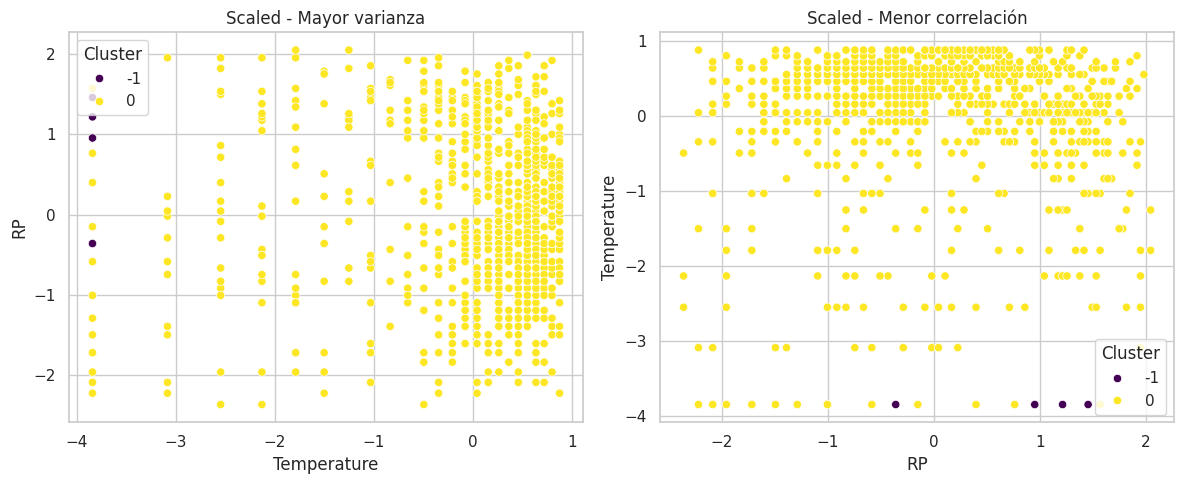

In [500]:
# Pon aquí tu código
def elegir_variables_visualizacion(df):
    varianzas = df.var()
    variables_mayor_varianza = varianzas.nlargest(2).index.tolist()

    correlaciones = df.corr().abs()
    correlaciones_triu = correlaciones.where(~np.tril(np.ones(correlaciones.shape)).astype(bool))
    menor_correlacion = correlaciones_triu.stack().sort_values().index[0]

    return variables_mayor_varianza, menor_correlacion

def visualizar_clusters(df, labels, nombre_dataset=""):
    df = df.copy()
    df['Cluster'] = labels

    vars_varianza, vars_correlacion = elegir_variables_visualizacion(df.drop(columns='Cluster'))

    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    sns.scatterplot(data=df, x=vars_varianza[0], y=vars_varianza[1], hue='Cluster', palette='viridis')
    plt.title(f'{nombre_dataset} - Mayor varianza')

    plt.subplot(1, 2, 2)
    sns.scatterplot(data=df, x=vars_correlacion[0], y=vars_correlacion[1], hue='Cluster', palette='viridis')
    plt.title(f'{nombre_dataset} - Menor correlación')

    plt.tight_layout()
    plt.show()


visualizar_clusters(df_scaled_dbscan, labels_dbscan_scaled, "Scaled")

Dado que solo el conjunto Scaled produjo resultados válidos, se ha utilizado exclusivamente para el análisis de visualización de clústeres.

Para representar gráficamente los clústeres detectados por DBSCAN, se seleccionaron dos pares de variables basados en criterios estadísticos:
- **Mayor Varianza**: Este criterio permite identificar aquellas dimensiones que más contribuyen a la separación natural de los datos. En este caso, las variables seleccionadas fueron RP y temperature. La visualización mostró que el clúster 0 se concentra principalmente en la parte derecha del gráfico, aunque con cierta dispersión, mientras que los pocos puntos clasificados como ruido (-1) se ubican a la izquierda aunque son pocos.
- **Menor correlación**: Evitar redundancia en la visualización. Las variables son las mismas que el caso anterior.

In [501]:
models = {
    'Scaled': dbscan_scaled,
    'PCA': dbscan_pca,
    'Final': dbscan_final
}

datasets = {
    'Scaled': df_scaled_dbscan,
    'PCA': df_pca_dbscan,
    'Final': df_final_dbscan
}

metrics_dbscan = {}

for name, model in models.items():
    labels = model.labels_
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    noise_ratio = (labels == -1).sum() / len(labels)

    if n_clusters > 1:
        silhouette = silhouette_score(datasets[name], labels)
        db_index = davies_bouldin_score(datasets[name], labels)
    else:
        silhouette = -1
        db_index = -1

    metrics_dbscan[name] = {
        'Silhouette': silhouette,
        'Davies-Bouldin': db_index,
        'N_Clusters': n_clusters,
        'Noise_Ratio': noise_ratio
    }

pd.DataFrame(metrics_dbscan).T

,Silhouette,Davies-Bouldin,N_Clusters,Noise_Ratio
Scaled,-1.0,-1.0,1.0,0.004237
PCA,-1.0,-1.0,1.0,0.584746
Final,-1.0,-1.0,1.0,0.962924


- **N_Clusters**: DBSCAN no identificó subgrupos claros en los datos.
- **Silhouette y Davies-Bouldin**: Dado a que hay un único clúster por conjunto de datos, no se ha podido calcular correctamente estas métricas.
- **Noise_Ratio**: Como se puedo observar con anterioridad, el conjunto de datos PCA y Final, tienen una gran cantidad de datos detectados como ruido, por lo que no encontró estructura en los datos. Sin embargo, Scaled solo tiene un 0.4% de datos detectados como ruido, casi ninguno.

## Dendrograma

In [502]:
df_scaled_dendro = df_scaled.copy()
df_pca_dendro = pd.DataFrame(df_pca)
df_final_dendro = df_final.copy()

In [503]:
#### Aplica el algoritmo de AgglomerativeClustering a los datos

In [504]:
## Pon aquí tu código
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram

clustering_model = AgglomerativeClustering(distance_threshold=0, n_clusters=None, linkage='ward')
clustering_model_scaled = clustering_model.fit(df_scaled_dendro)
clustering_model_pca = clustering_model.fit(df_pca_dendro)
clustering_model_final = clustering_model.fit(df_final_dendro)

In [505]:
def plot_dendrogram(model, **kwargs):
    counts = np.zeros(model.children_.shape[0])
    n_samples = len(model.labels_)
    for i, merge in enumerate(model.children_):
        current_count = 0
        for child_idx in merge:
            if child_idx < n_samples:
                current_count += 1
            else:
                current_count += counts[child_idx - n_samples]
        counts[i] = current_count

    linkage_matrix = np.column_stack([model.children_, model.distances_, counts]).astype(float)

    dendrogram(linkage_matrix, **kwargs)

    plt.title("Hierarchical clustering")
    plt.ylabel("Distance")
    plt.xlabel("Texts")
    plt.show()

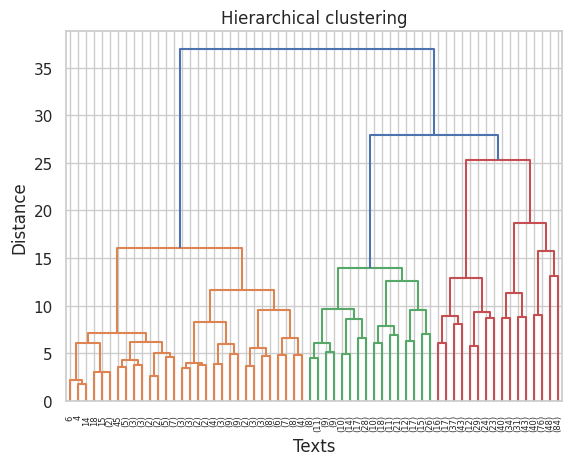

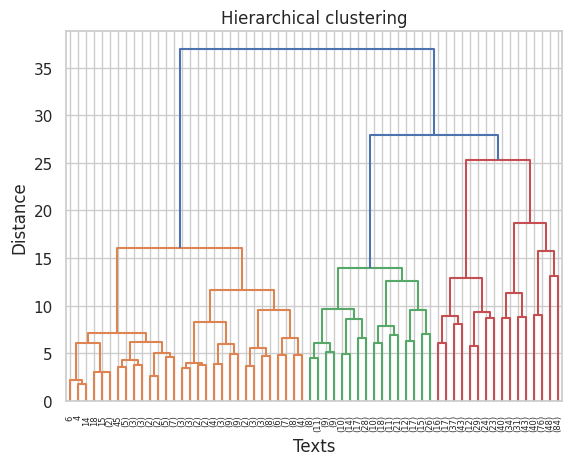

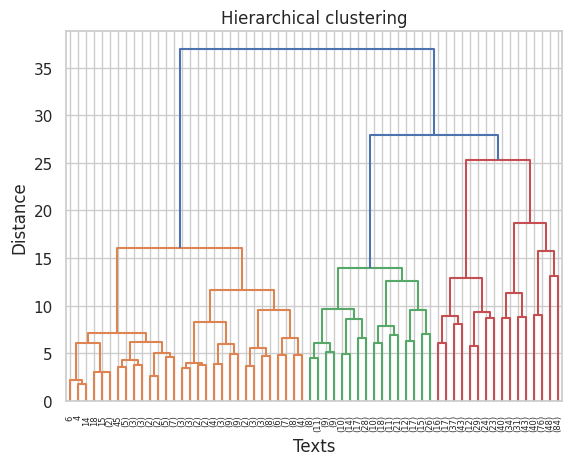

In [506]:
plot_dendrogram(clustering_model_scaled, truncate_mode='level', p=5)
plot_dendrogram(clustering_model_pca, truncate_mode='level', p=5)
plot_dendrogram(clustering_model_final, truncate_mode='level', p=5)

In [507]:
#### Realiza un análisis de cuál es el número ideal de clústeres y explique el porqué de su elección

Al analizar los dendrogramas generados, se observa que solo en la altura 1 no se forman tres clústeres. Este comportamiento es consistente en las tres representaciones de los datos: las variables escaladas, las componentes principales (PCA) y las variables finales.

In [508]:
#### Aplica de nuevo el clustering jerárquico con el número de clústeres elegido y crea un dataframe con los datos y las etiquetas otorgadas por el algoritmo.

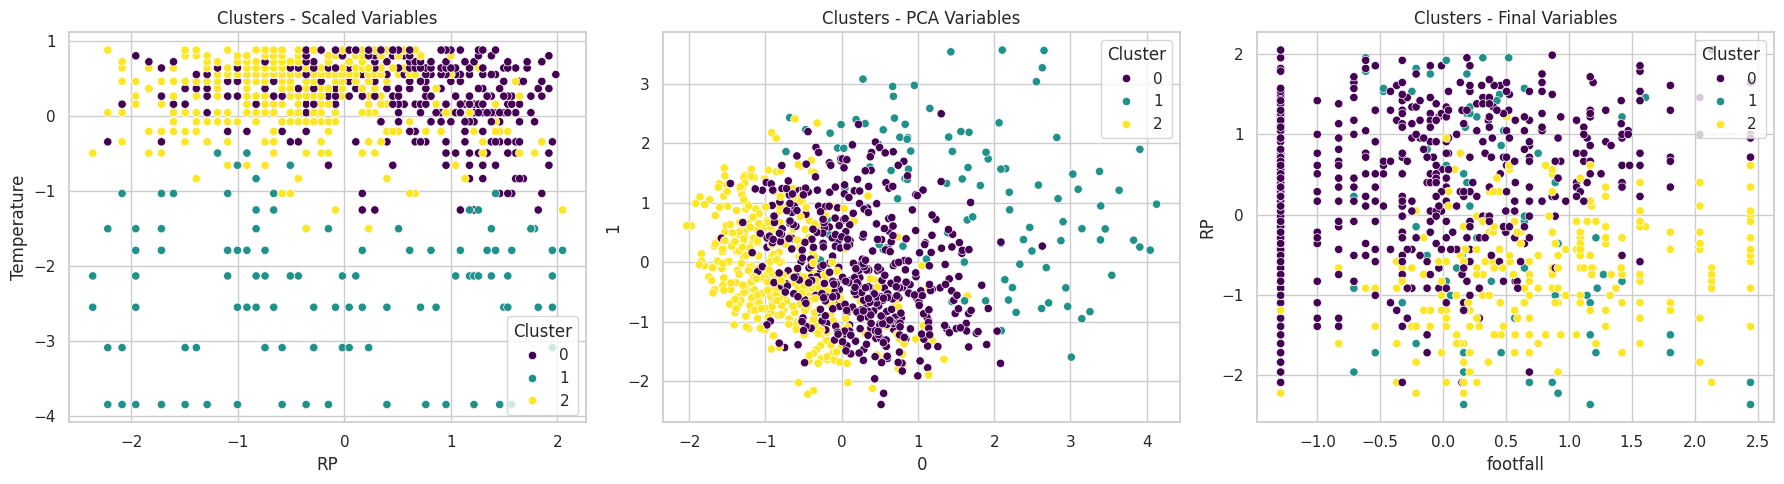

In [509]:
sns.set(style="whitegrid")

model_scaled = AgglomerativeClustering(n_clusters=3, linkage='ward')
model_pca = AgglomerativeClustering(n_clusters=3, linkage='ward')
model_final = AgglomerativeClustering(n_clusters=3, linkage='ward')

df_scaled_dendro['Cluster'] = model_scaled.fit_predict(df_scaled_dendro)
df_pca_dendro['Cluster'] = model_pca.fit_predict(df_pca_dendro)
df_final_dendro['Cluster'] = model_final.fit_predict(df_final_dendro)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes = axes.flatten()

sns.scatterplot(data=df_scaled_dendro, x='RP', y='Temperature', hue='Cluster', palette='viridis', ax=axes[0])
axes[0].set_title('Clusters - Scaled Variables')

sns.scatterplot(data=df_pca_dendro, x=0, y=1, hue='Cluster', palette='viridis', ax=axes[1])
axes[1].set_title('Clusters - PCA Variables')

sns.scatterplot(data=df_final_dendro, x='footfall', y='RP', hue='Cluster', palette='viridis', ax=axes[2])
axes[2].set_title('Clusters - Final Variables')

plt.tight_layout()
plt.show()


In [510]:
datasets = {
    'Scaled': (df_scaled_dendro.drop(columns=['Cluster']), model_scaled.labels_),
    'PCA': (df_pca_dendro.drop(columns=['Cluster']), model_pca.labels_),
    'Final': (df_final_dendro.drop(columns=['Cluster']), model_final.labels_)
}

metrics_results = {}

for name, (data, labels) in datasets.items():
    silhouette = silhouette_score(data, labels) if len(set(labels)) > 1 else -1
    davies_bouldin = davies_bouldin_score(data, labels)
    calinski_harabasz = calinski_harabasz_score(data, labels)
    n_clusters = len(set(labels))

    metrics_results[name] = {
        'Silhouette': silhouette,
        'Davies-Bouldin': davies_bouldin,
        'Calinski-Harabasz': calinski_harabasz,
        'N_Clusters': n_clusters
    }

metrics_df = pd.DataFrame(metrics_results).T
metrics_df

,Silhouette,Davies-Bouldin,Calinski-Harabasz,N_Clusters
Scaled,0.257376,1.318427,339.928518,3.0
PCA,0.085971,2.679717,99.657989,3.0
Final,0.071147,2.728426,87.039208,3.0


- **Silhouette Score**: El dataset Scaled tiene el mejor valor (0.257), indicando que los clústeres están mejor separados en comparación con los demás. Mientras que los otros dos tienen valores muy bajos (0.08 y 0.07).
- **Davies-Bouldin Index**: El índice más bajo es el de Scaled (1.318), lo cual indica una menor superposición entre clústeres.
- **Calinski-Harabasz Index**: De nuevo, Scaled sobresale con un valor de 339.93, muy superior al de los otros datasets. Esto muestra que la separación y la definición de los clústeres es considerablemente mejor.
- **N_Clusters**: En los tres casos se detectaron 3 clústeres, tal y como se había seleccionado.

## Análisis

#### Realiza un análisis detallado de cada uno de los grupos generados por los algoritmos aplicados anteriormente y decide cuál es el mejor método para el conjunto de datos.
Utiliza gráficos o tablas para apoyar tus conclusiones

En este análisis, se exploran los resultados obtenidos con tres técnicas de clustering: K-means, DBSCAN y Clustering Jerárquico (Dendrograma). Cada uno de estos métodos ha sido aplicado a tres conjuntos de datos: Scaled, PCA y Final.

- **K-means**
  - El modelo de K-means funciona bien para el conjunto de datos escalado, donde los clústeres se separan claramente según las variables. Los Silhouette Scores son moderadamente buenos, lo que sugiere una segmentación efectiva.
  - En el conjunto de datos PCA y Final, el Silhouette Score es bajo, lo que indica que los clústeres no están bien definidos.
- **DBSCAN**
  - Detecta bien un único clúster en el conjunto escalado con un Silhouette Score razonable y un bajo nivel de ruido.
  - No detecta múltiples clústeres y tiene un desempeño deficiente en los otros conjuntos, especialmente en PCA y Final, donde considera muchos puntos como ruido.
- **Dendrograma**
  - Ofrece una buena separación de los datos en tres clústeres en el conjunto escalado, pero no tiene un Silhouette Score excelente.
  - El desempeño en los conjuntos PCA y Final es pobre, con puntuaciones muy bajas en Silhouette y Calinski-Harabasz.

K-means en el conjunto de datos escalados es el mejor método, ya que ofrece un buen balance entre la calidad del clustering y la interpretabilidad. En los otros conjuntos, DBSCAN y Clustering Jerárquico no proporcionan buenos resultados.